<a href="https://colab.research.google.com/github/ebitnet65/geometry-of-thermodynamics-review/blob/master/Liouville_Curvature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Python code for computing 3rd order responses.

This notenbook generates the figures in our paper

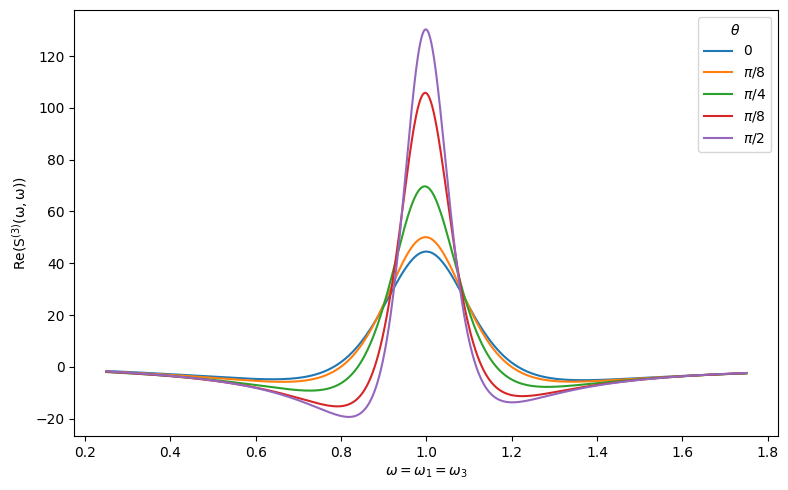

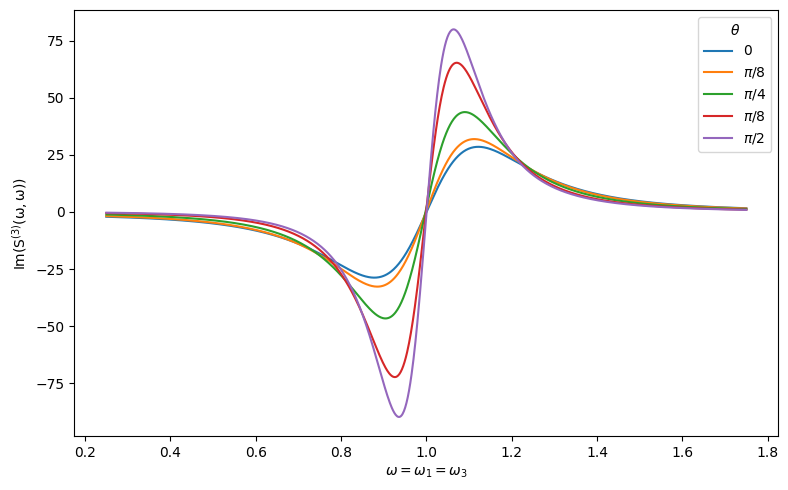

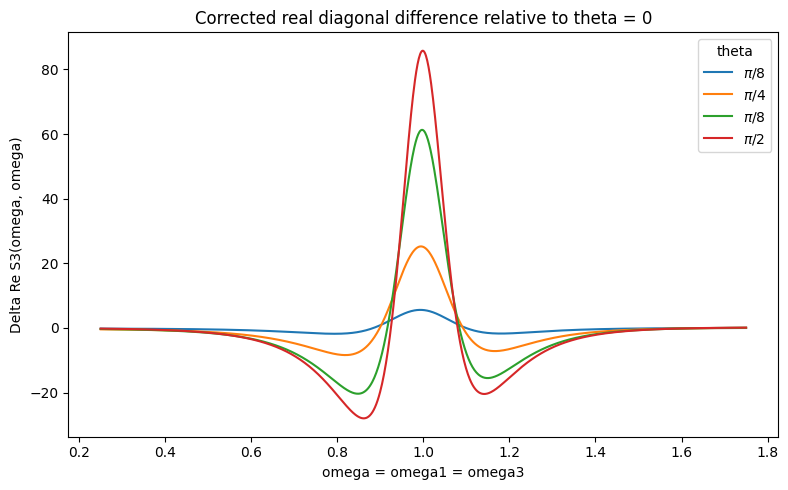

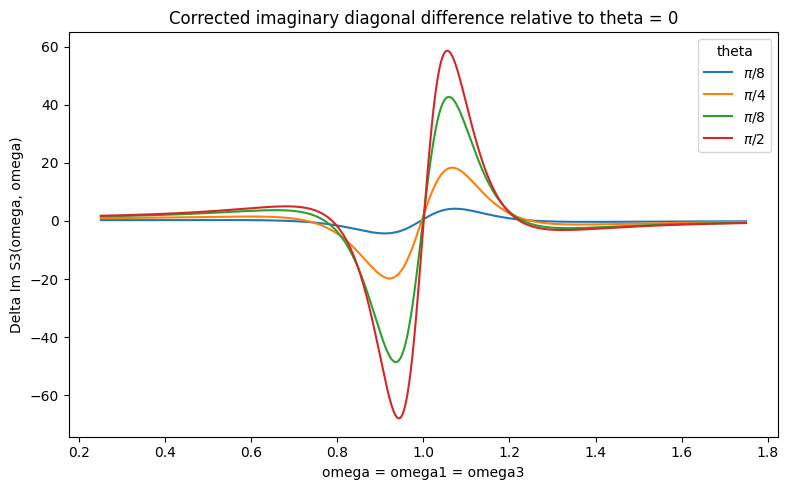

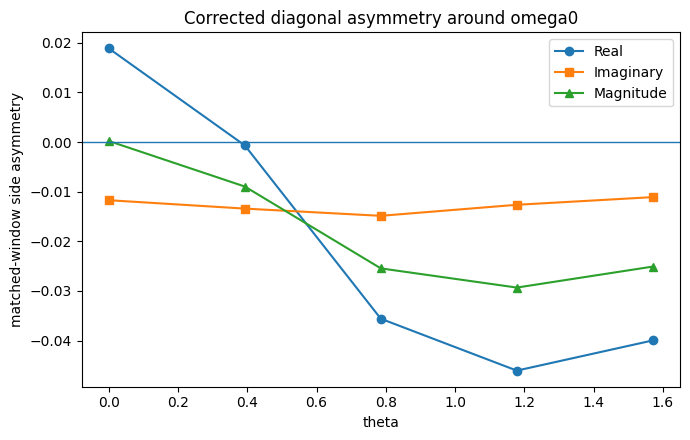

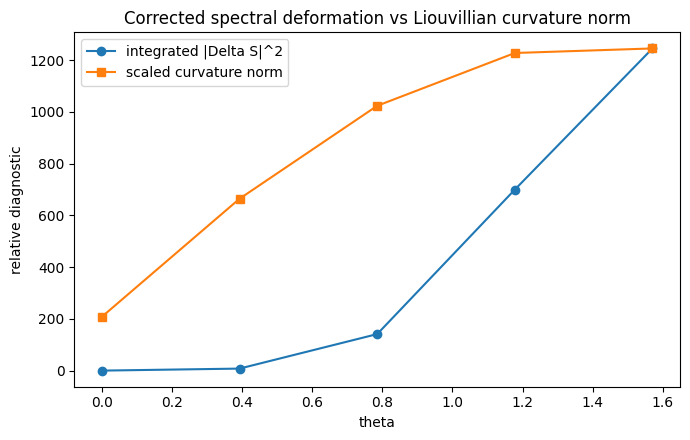

Finite-window KK check, theta = 0
best-fit Hilbert scale: 1.0325506078352191
relative KK residual: 0.08275783759370513


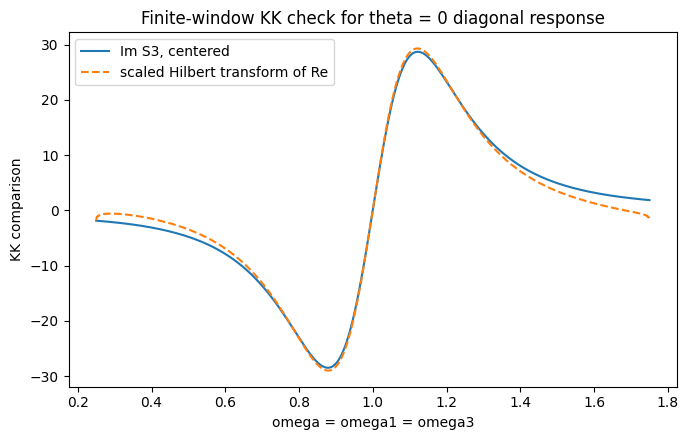

In [1]:
# Python code used for corrected diagonal theta sweeps and KK check.
# Requires: numpy, scipy, matplotlib

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from numpy import kron
from scipy.signal import hilbert

I2 = np.eye(2, dtype=complex)
sig_x = np.array([[0, 1], [1, 0]], dtype=complex)
sig_z = np.array([[-1, 0], [0, 1]], dtype=complex)
sig_p = np.array([[0, 0], [1, 0]], dtype=complex)
sig_m = np.array([[0, 1], [0, 0]], dtype=complex)
mu = sig_p + sig_m

def comm_super(O):
    return kron(I2, O) - kron(O.T, I2)

def liouvillian(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02):
    H = 0.5 * w0 * sig_z
    L = -1j * (kron(I2, H) - kron(H.T, I2))

    A = np.cos(theta) * sig_z + np.sin(theta) * sig_x
    C = np.sqrt(gamma_phi) * A
    CdC = C.conj().T @ C
    L += kron(C.conj(), C) - 0.5 * kron(I2, CdC) - 0.5 * kron(CdC.T, I2)

    if gamma1 > 0:
        C1 = np.sqrt(gamma1) * sig_m
        CdC1 = C1.conj().T @ C1
        L += kron(C1.conj(), C1) - 0.5 * kron(I2, CdC1) - 0.5 * kron(CdC1.T, I2)

    return L

def G_freq(L, omega, eta=1e-3):
    n = L.shape[0]
    return -np.linalg.inv(L + (1j * omega - eta) * np.eye(n))

def signal_point_diag(theta, omega, tau2=1.0, w0=1.0, gamma_phi=0.1, gamma1=0.02):
    L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=theta, gamma1=gamma1)
    J = comm_super(mu)
    rho0 = np.array([[1, 0], [0, 0]], dtype=complex).reshape(-1, order="F")
    U2 = scipy.linalg.expm(L * tau2)
    G = G_freq(L, omega)
    rho_vec = G @ J @ U2 @ J @ G @ J @ rho0
    rho = rho_vec.reshape((2, 2), order="F")
    return np.trace(mu @ rho)

def dL_dtheta(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02, h=1e-5):
    return (
        liouvillian(w0, gamma_phi, theta + h, gamma1)
        - liouvillian(w0, gamma_phi, theta - h, gamma1)
    ) / (2 * h)

def dL_dgamma(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02, h=1e-5):
    return (
        liouvillian(w0, gamma_phi + h, theta, gamma1)
        - liouvillian(w0, gamma_phi - h, theta, gamma1)
    ) / (2 * h)

def curvature_norm(theta, w0=1.0, gamma_phi=0.1, gamma1=0.02,
                   g_beta=-0.03, theta_beta=-0.05):
    L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=theta, gamma1=gamma1)
    dLbeta = (
        g_beta * dL_dgamma(w0, gamma_phi, theta, gamma1)
        + theta_beta * dL_dtheta(w0, gamma_phi, theta, gamma1)
    )
    F = L @ dLbeta - dLbeta @ L
    return np.linalg.norm(F)

# Parameters
w0 = 1.0
omega0 = 1.0
gamma_phi = 0.1
gamma1 = 0.02
tau2 = 1.0

delta = 0.75
omegas = np.linspace(omega0 - delta, omega0 + delta, 1001)

theta_values = np.array([
    0,
    np.pi / 8,
    np.pi / 4,
    3 * np.pi / 8,
    np.pi / 2
])
theta_labels = ["0", r'$\pi/8$', r'$\pi/4$', r'$\pi/8$', r'$\pi/2$']

diag_signals = []
for th in theta_values:
    diag_signals.append(
        np.array([
            signal_point_diag(th, om, tau2, w0, gamma_phi, gamma1)
            for om in omegas
        ])
    )
diag_signals = np.array(diag_signals)
S_ref = diag_signals[0]

diff_integrals = np.array([
    np.trapezoid(np.abs(S - S_ref)**2, omegas)
    for S in diag_signals
])
curv_norms = np.array([
    curvature_norm(th, w0, gamma_phi, gamma1)
    for th in theta_values
])

left = omegas < omega0
right = omegas > omega0

def matched_asymmetry(S, component="abs"):
    Re = np.real(S)
    Im = np.imag(S)
    Abs = np.abs(S)

    x_left = omega0 - omegas[left][::-1]
    x_right = omegas[right] - omega0
    x_common = np.linspace(0, min(x_left[-1], x_right[-1]), 500)

    if component == "real":
        yL = np.interp(x_common, x_left, np.abs(Re[left][::-1]))
        yR = np.interp(x_common, x_right, np.abs(Re[right]))
    elif component == "imag":
        yL = np.interp(x_common, x_left, np.abs(Im[left][::-1]))
        yR = np.interp(x_common, x_right, np.abs(Im[right]))
    else:
        yL = np.interp(x_common, x_left, Abs[left][::-1])
        yR = np.interp(x_common, x_right, Abs[right])

    Lw = np.trapezoid(yL, x_common)
    Rw = np.trapezoid(yR, x_common)
    return (Rw - Lw) / (Rw + Lw)

asym_re = np.array([matched_asymmetry(S, "real") for S in diag_signals])
asym_im = np.array([matched_asymmetry(S, "imag") for S in diag_signals])
asym_abs = np.array([matched_asymmetry(S, "abs") for S in diag_signals])

# Plot corrected real diagonal sweep
plt.figure(figsize=(8, 5))
for S, lab in zip(diag_signals, theta_labels):
    plt.plot(omegas, np.real(S), label=lab)
plt.xlabel(r'$\omega = \omega_1 = \omega_3$')
plt.ylabel(r'$\rm{Re}(S^{(3)}(\omega, \omega))$')
#plt.title("Corrected matched-window real diagonal sweep")
plt.legend(title=r'$\theta$')
plt.tight_layout()
plt.savefig("corrected_diag_theta_real.png", dpi=200)
plt.show()

# Plot corrected imaginary diagonal sweep
plt.figure(figsize=(8, 5))
for S, lab in zip(diag_signals, theta_labels):
    plt.plot(omegas, np.imag(S), label=lab)
plt.xlabel(r'$\omega = \omega_1 = \omega_3$')
plt.ylabel(r'$\rm{Im}(S^{(3)}(\omega, \omega))$')
#plt.title("Corrected matched-window imaginary diagonal sweep")
plt.legend(title=r'$\theta$')
plt.tight_layout()
plt.savefig("corrected_diag_theta_imag.png", dpi=200)
plt.show()

# Real difference from theta = 0
plt.figure(figsize=(8, 5))
for S, lab in zip(diag_signals[1:], theta_labels[1:]):
    plt.plot(omegas, np.real(S - S_ref), label=lab)
plt.xlabel("omega = omega1 = omega3")
plt.ylabel("Delta Re S3(omega, omega)")
plt.title("Corrected real diagonal difference relative to theta = 0")
plt.legend(title="theta")
plt.tight_layout()
plt.savefig("corrected_diag_theta_real_difference.png", dpi=200)
plt.show()

# Imaginary difference from theta = 0
plt.figure(figsize=(8, 5))
for S, lab in zip(diag_signals[1:], theta_labels[1:]):
    plt.plot(omegas, np.imag(S - S_ref), label=lab)
plt.xlabel("omega = omega1 = omega3")
plt.ylabel("Delta Im S3(omega, omega)")
plt.title("Corrected imaginary diagonal difference relative to theta = 0")
plt.legend(title="theta")
plt.tight_layout()
plt.savefig("corrected_diag_theta_imag_difference.png", dpi=200)
plt.show()

# Corrected asymmetry
plt.figure(figsize=(7, 4.5))
plt.plot(theta_values, asym_re, marker="o", label="Real")
plt.plot(theta_values, asym_im, marker="s", label="Imaginary")
plt.plot(theta_values, asym_abs, marker="^", label="Magnitude")
plt.axhline(0, linewidth=1)
plt.xlabel("theta")
plt.ylabel("matched-window side asymmetry")
plt.title("Corrected diagonal asymmetry around omega0")
plt.legend()
plt.tight_layout()
plt.savefig("corrected_diag_theta_asymmetry.png", dpi=200)
plt.show()

# Spectral deformation vs curvature norm
plt.figure(figsize=(7, 4.5))
scaled_curv = curv_norms / np.max(curv_norms) * np.max(diff_integrals)
plt.plot(theta_values, diff_integrals, marker="o", label="integrated |Delta S|^2")
plt.plot(theta_values, scaled_curv, marker="s", label="scaled curvature norm")
plt.xlabel("theta")
plt.ylabel("relative diagnostic")
plt.title("Corrected spectral deformation vs Liouvillian curvature norm")
plt.legend()
plt.tight_layout()
plt.savefig("corrected_theta_diagnostics.png", dpi=200)
plt.show()

# Finite-window Kramers--Kronig diagnostic for theta = 0
S0 = diag_signals[0]
Re0 = np.real(S0)
Im0 = np.imag(S0)

Re0_centered = Re0 - 0.5 * (Re0[0] + Re0[-1])
Im0_centered = Im0 - 0.5 * (Im0[0] + Im0[-1])

H_Re = np.imag(hilbert(Re0_centered))
scale = np.dot(H_Re, Im0_centered) / np.dot(H_Re, H_Re)
kk_resid = Im0_centered - scale * H_Re
rel_kk_error = np.linalg.norm(kk_resid) / np.linalg.norm(Im0_centered)

print("Finite-window KK check, theta = 0")
print("best-fit Hilbert scale:", scale)
print("relative KK residual:", rel_kk_error)

plt.figure(figsize=(7, 4.5))
plt.plot(omegas, Im0_centered, label="Im S3, centered")
plt.plot(omegas, scale * H_Re, linestyle="--",
         label="scaled Hilbert transform of Re")
plt.xlabel("omega = omega1 = omega3")
plt.ylabel("KK comparison")
plt.title("Finite-window KK check for theta = 0 diagonal response")
plt.legend()
plt.tight_layout()
plt.savefig("corrected_theta0_KK_check.png", dpi=200)
plt.show()


#--------------TESTING RP and NRP ROBUSTNESS




max abs Re(F) = 0.0011581132268940462
max abs Im(F) = 0.06162264539312511
F(theta = 0):
[[ 0.     +0.j     0.00095+0.005j  0.00095-0.005j  0.     +0.j   ]
 [-0.00105-0.005j  0.     +0.j     0.     +0.j     0.00085+0.005j]
 [-0.00105+0.005j  0.     +0.j     0.     +0.j     0.00085-0.005j]
 [ 0.     +0.j    -0.00095-0.005j -0.00095+0.005j  0.     +0.j   ]]
F(theta = pi/2):
[[-4.00000000e-04+0.j     8.50000000e-04+0.015j  8.50000000e-04-0.015j
  -4.00000000e-04+0.j   ]
 [-1.15000000e-03-0.015j  0.00000000e+00+0.j    -8.67361738e-19+0.04j
   5.50000000e-04+0.015j]
 [-1.15000000e-03+0.015j  8.67361738e-19-0.04j   0.00000000e+00+0.j
   5.50000000e-04-0.015j]
 [ 4.00000000e-04+0.j    -8.50000000e-04-0.015j -8.50000000e-04+0.015j
   4.00000000e-04+0.j   ]]


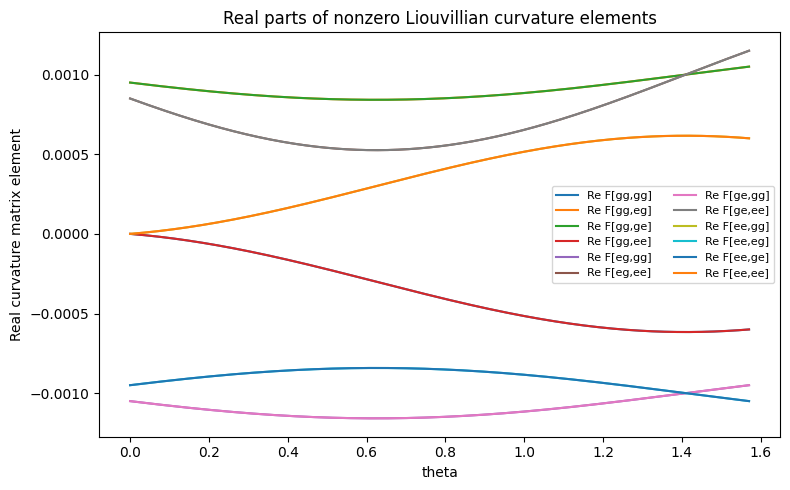

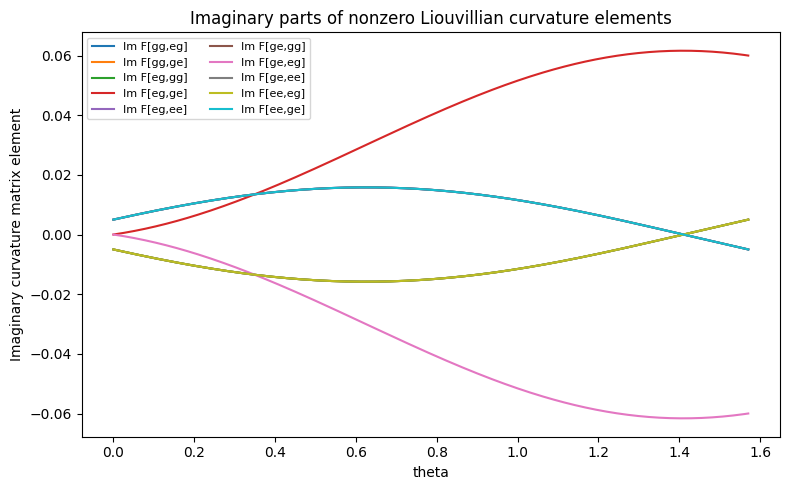

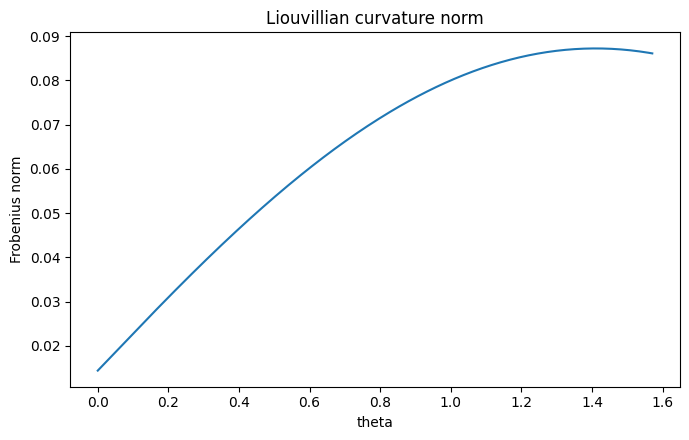

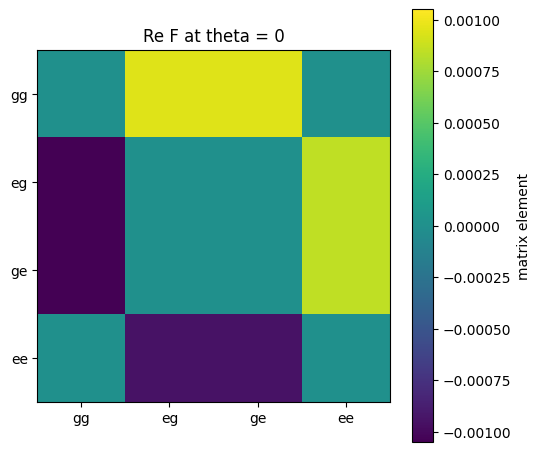

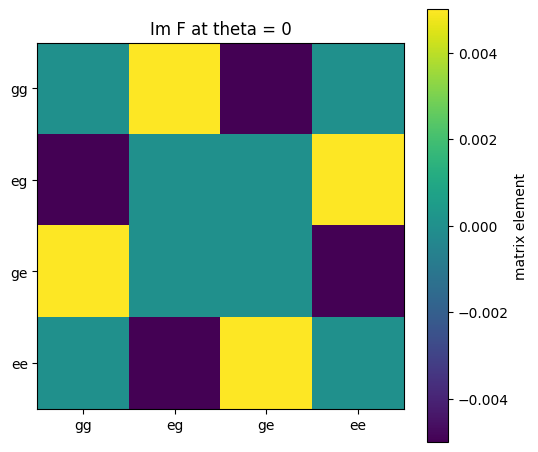

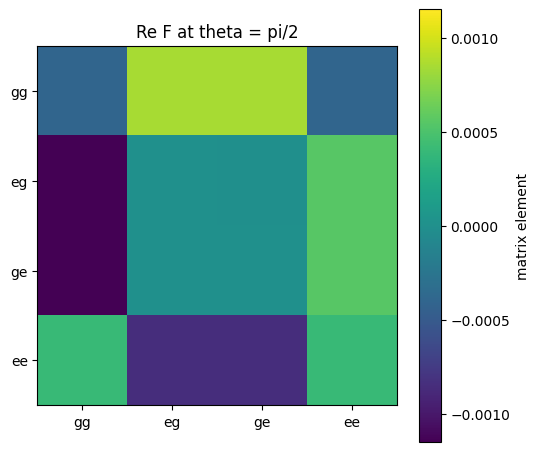

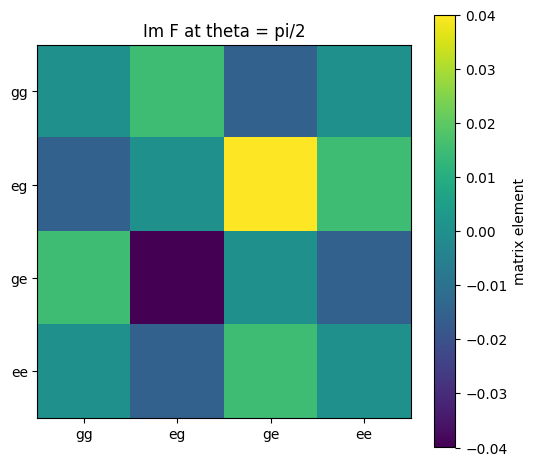

In [ ]:
# curvature_plots.py
# Generates Liouvillian curvature tensor plots for the rotated-dephasing 2LS.
#
# Requires:
#   numpy
#   matplotlib
#
# Output files:
#   curvature_real_elements_theta.png
#   curvature_imag_elements_theta.png
#   curvature_norm_theta_dense.png
#   curvature_Re_theta0.png
#   curvature_Im_theta0.png
#   curvature_Re_thetapi2.png
#   curvature_Im_thetapi2.png

import numpy as np
import matplotlib.pyplot as plt
from numpy import kron


# ---------------------------------------------------------------------
# Basic two-level-system operators
# ---------------------------------------------------------------------

I2 = np.eye(2, dtype=complex)

sig_x = np.array(
    [
        [0, 1],
        [1, 0],
    ],
    dtype=complex,
)

sig_z = np.array(
    [
        [-1, 0],
        [0, 1],
    ],
    dtype=complex,
)

sig_p = np.array(
    [
        [0, 0],
        [1, 0],
    ],
    dtype=complex,
)

sig_m = np.array(
    [
        [0, 1],
        [0, 0],
    ],
    dtype=complex,
)


# ---------------------------------------------------------------------
# Liouvillian and numerical derivatives
# ---------------------------------------------------------------------

def liouvillian(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02):
    """Column-stacked Lindblad Liouvillian.

    The vectorization convention is order="F". For a 2x2 density matrix,
    the induced basis ordering is

        |gg>>, |eg>>, |ge>>, |ee>>.

    Parameters
    ----------
    w0 : float
        Transition frequency.
    gamma_phi : float
        Pure-dephasing strength.
    theta : float
        Rotation angle of the environmental pointer axis.
    gamma1 : float
        Population-relaxation rate for |e> -> |g>.
    """

    H = 0.5 * w0 * sig_z

    # Hamiltonian part: vec(-i[H,rho]).
    L = -1j * (kron(I2, H) - kron(H.T, I2))

    # Rotated dephasing axis.
    A = np.cos(theta) * sig_z + np.sin(theta) * sig_x
    C = np.sqrt(gamma_phi) * A
    CdC = C.conj().T @ C

    L += (
        kron(C.conj(), C)
        - 0.5 * kron(I2, CdC)
        - 0.5 * kron(CdC.T, I2)
    )

    # Population relaxation |e> -> |g>.
    if gamma1 > 0:
        C1 = np.sqrt(gamma1) * sig_m
        CdC1 = C1.conj().T @ C1
        L += (
            kron(C1.conj(), C1)
            - 0.5 * kron(I2, CdC1)
            - 0.5 * kron(CdC1.T, I2)
        )

    return L


def dL_dtheta(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02, h=1.0e-5):
    """Central finite-difference derivative dL/dtheta."""

    return (
        liouvillian(w0, gamma_phi, theta + h, gamma1)
        - liouvillian(w0, gamma_phi, theta - h, gamma1)
    ) / (2.0 * h)


def dL_dgamma(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02, h=1.0e-5):
    """Central finite-difference derivative dL/dgamma_phi."""

    return (
        liouvillian(w0, gamma_phi + h, theta, gamma1)
        - liouvillian(w0, gamma_phi - h, theta, gamma1)
    ) / (2.0 * h)


def curvature_matrix(
    theta,
    w0=1.0,
    gamma_phi=0.1,
    gamma1=0.02,
    g_beta=-0.03,
    theta_beta=-0.05,
):
    """Compute F_{t beta} = [L, d_beta L].

    The beta derivative is modeled as

        d_beta L =
            g_beta d_{gamma_phi} L + theta_beta d_theta L.

    """

    L = liouvillian(
        w0=w0,
        gamma_phi=gamma_phi,
        theta=theta,
        gamma1=gamma1,
    )

    dLbeta = (
        g_beta * dL_dgamma(w0, gamma_phi, theta, gamma1)
        + theta_beta * dL_dtheta(w0, gamma_phi, theta, gamma1)
    )

    return L @ dLbeta - dLbeta @ L


# ---------------------------------------------------------------------
# Sweep over theta
# ---------------------------------------------------------------------

w0 = 1.0
gamma_phi = 0.1
gamma1 = 0.02
g_beta = -0.03
theta_beta = -0.05

theta_grid = np.linspace(0.0, np.pi/2, 301)

F_grid = np.array(
    [
        curvature_matrix(
            th,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            g_beta=g_beta,
            theta_beta=theta_beta,
        )
        for th in theta_grid
    ]
)

real_max = np.max(np.abs(np.real(F_grid)))
imag_max = np.max(np.abs(np.imag(F_grid)))
fro_norm = np.linalg.norm(F_grid.reshape(len(theta_grid), -1), axis=1)

print("max abs Re(F) =", real_max)
print("max abs Im(F) =", imag_max)
print("F(theta = 0):")
print(F_grid[0])
print("F(theta = pi/2):")
print(F_grid[len(theta_grid) // 2])


# ---------------------------------------------------------------------
# Plot matrix elements as functions of theta
# ---------------------------------------------------------------------

threshold = 1.0e-6
nonzero_real = []
nonzero_imag = []

for i in range(4):
    for j in range(4):
        if np.max(np.abs(np.real(F_grid[:, i, j]))) > threshold:
            nonzero_real.append((i, j))
        if np.max(np.abs(np.imag(F_grid[:, i, j]))) > threshold:
            nonzero_imag.append((i, j))

basis_labels = ["gg", "eg", "ge", "ee"]

plt.figure(figsize=(8, 5))
for i, j in nonzero_real:
    plt.plot(
        theta_grid,
        np.real(F_grid[:, i, j]),
        label=f"Re F[{basis_labels[i]},{basis_labels[j]}]",
    )
plt.xlabel("theta")
plt.ylabel("Real curvature matrix element")
plt.title("Real parts of nonzero Liouvillian curvature elements")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("curvature_real_elements_theta.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 5))
for i, j in nonzero_imag:
    plt.plot(
        theta_grid,
        np.imag(F_grid[:, i, j]),
        label=f"Im F[{basis_labels[i]},{basis_labels[j]}]",
    )
plt.xlabel("theta")
plt.ylabel("Imaginary curvature matrix element")
plt.title("Imaginary parts of nonzero Liouvillian curvature elements")
plt.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("curvature_imag_elements_theta.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4.5))
plt.plot(theta_grid, fro_norm)
plt.xlabel("theta")
plt.ylabel("Frobenius norm")
plt.title("Liouvillian curvature norm")
plt.tight_layout()
plt.savefig("curvature_norm_theta_dense.png", dpi=200)
plt.show()


# ---------------------------------------------------------------------
# Representative matrix heat maps
# ---------------------------------------------------------------------

def plot_matrix_heatmap(M, title, filename):
    vmax = np.max(np.abs(M))
    if vmax == 0:
        vmax = 1.0

    plt.figure(figsize=(5.5, 4.8))
    plt.imshow(M, vmin=-vmax, vmax=vmax)
    plt.xticks(range(4), basis_labels)
    plt.yticks(range(4), basis_labels)
    plt.colorbar(label="matrix element")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=200)
    plt.show()


F0 = F_grid[0]
Fmid = F_grid[len(theta_grid) // 2]

plot_matrix_heatmap(
    np.real(F0),
    "Re F at theta = 0",
    "curvature_Re_theta0.png",
)

plot_matrix_heatmap(
    np.imag(F0),
    "Im F at theta = 0",
    "curvature_Im_theta0.png",
)

plot_matrix_heatmap(
    np.real(Fmid),
    "Re F at theta = pi/2",
    "curvature_Re_thetapi2.png",
)

plot_matrix_heatmap(
    np.imag(Fmid),
    "Im F at theta = pi/2",
    "curvature_Im_thetapi2.png",
)


theta, first_order_error, second_order_error, deformation
0.0000  0.000000  0.000000  0.000000
0.0524  0.001904  0.000002  0.001907
0.1047  0.007595  0.000031  0.007641
0.1571  0.017005  0.000156  0.017239
0.2094  0.030024  0.000487  0.030759
0.2618  0.046498  0.001173  0.048286
0.3142  0.066230  0.002392  0.069919
0.3665  0.088985  0.004344  0.095777
0.4189  0.114486  0.007240  0.125988
0.4712  0.142426  0.011290  0.160686
0.5236  0.172461  0.016692  0.200002
0.5760  0.204224  0.023620  0.244053
0.6283  0.237323  0.032208  0.292926
0.6807  0.271349  0.042540  0.346668
0.7330  0.305886  0.054645  0.405257
0.7854  0.340513  0.068481  0.468587
0.8378  0.374813  0.083940  0.536434
0.8901  0.408382  0.100844  0.608431
0.9425  0.440838  0.118951  0.684035
0.9948  0.471820  0.137969  0.762498
1.0472  0.501005  0.157576  0.842838
1.0996  0.528103  0.177440  0.923829
1.1519  0.552867  0.197257  1.003990
1.2043  0.575090  0.216791  1.081604
1.2566  0.594605  0.235923  1.154763
1.3090  0.611284 

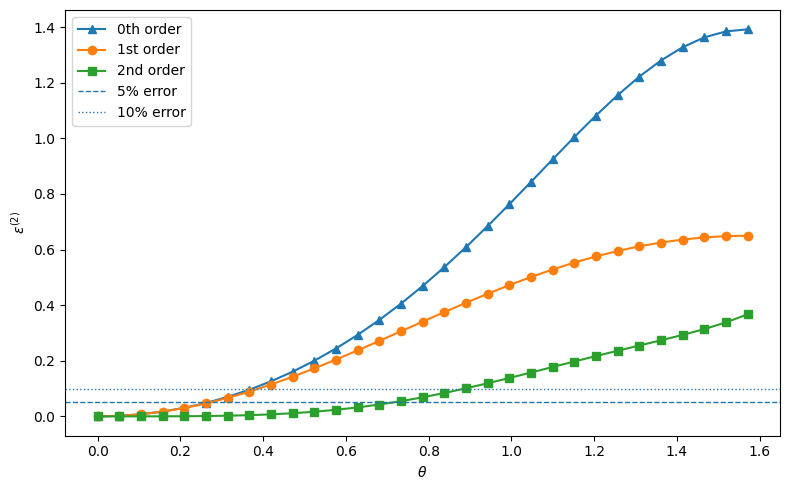

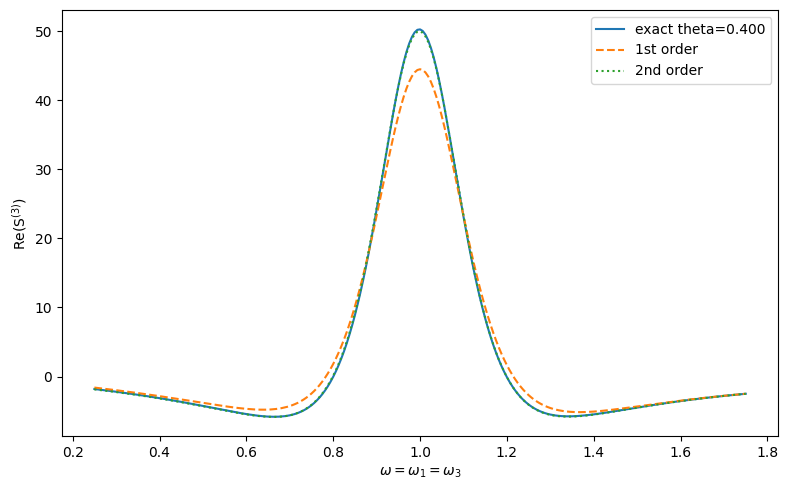

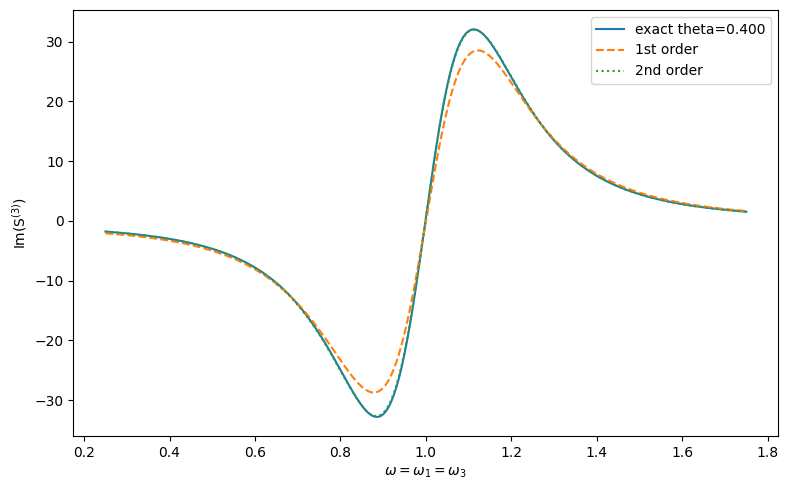

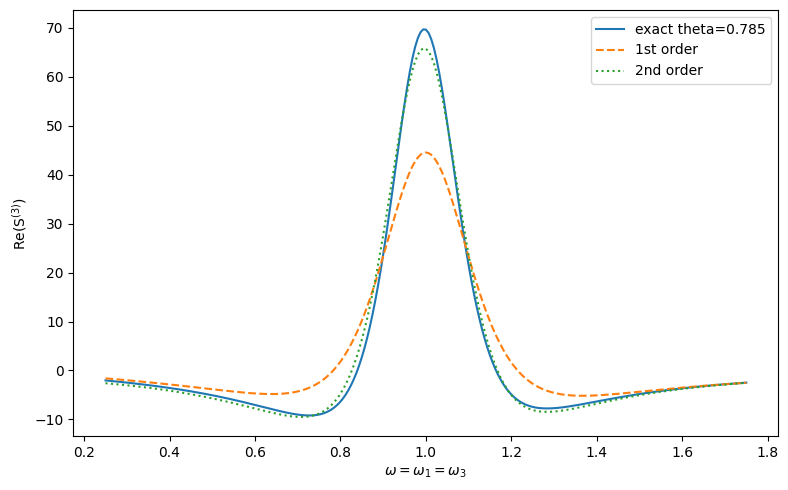

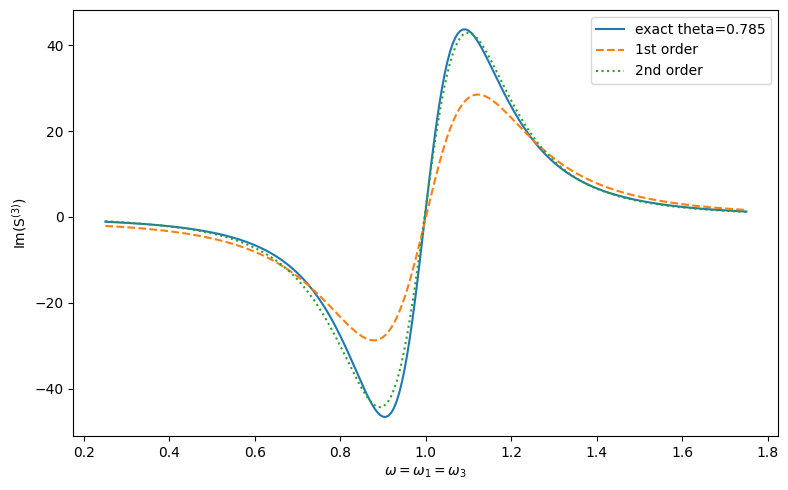

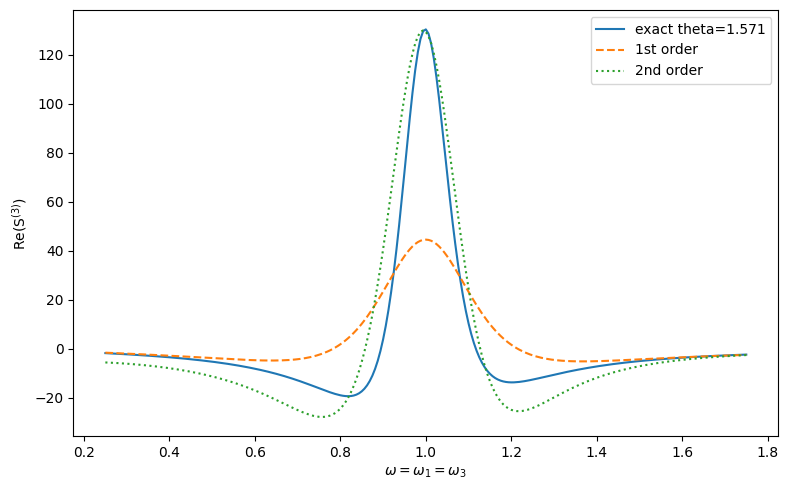

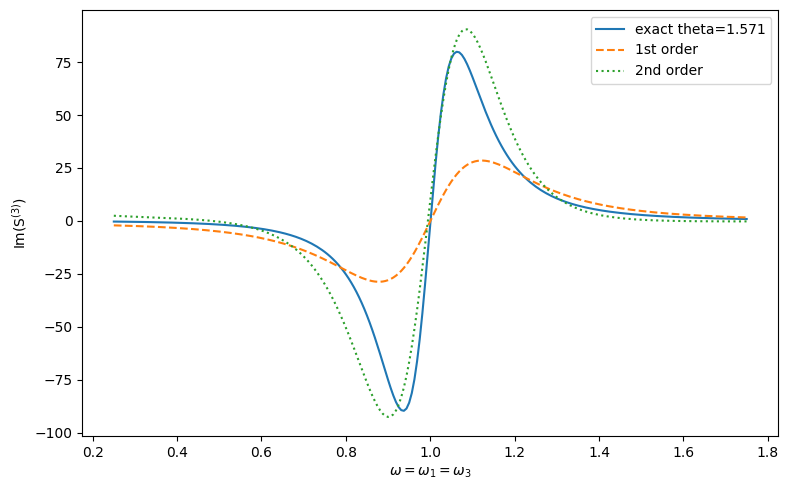

In [ ]:
# duhamel_second_order_reconstruction.py
# Numerical test of first- and second-order Duhamel/resolvent reconstruction
# for a rotated-dephasing two-level system.
#
# Requires:
#   numpy
#   scipy
#   matplotlib
#
# Output figures:
#   duhamel_second_order_error_scaling.png
#   duhamel_second_order_real_theta_0p4.png
#   duhamel_second_order_imag_theta_0p4.png
#   duhamel_second_order_real_theta_0p785.png
#   duhamel_second_order_imag_theta_0p785.png
#   duhamel_second_order_real_theta_1p571.png
#   duhamel_second_order_imag_theta_1p571.png

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from numpy import kron


# ---------------------------------------------------------------------
# Operators
# ---------------------------------------------------------------------

I2 = np.eye(2, dtype=complex)

sig_x = np.array(
    [
        [0, 1],
        [1, 0],
    ],
    dtype=complex,
)

sig_z = np.array(
    [
        [-1, 0],
        [0, 1],
    ],
    dtype=complex,
)

sig_m = np.array(
    [
        [0, 1],
        [0, 0],
    ],
    dtype=complex,
)

sig_p = np.array(
    [
        [0, 0],
        [1, 0],
    ],
    dtype=complex,
)

mu = sig_p + sig_m


# ---------------------------------------------------------------------
# Superoperators
# ---------------------------------------------------------------------

def comm_super(O):
    """Return the commutator superoperator vec([O,rho])."""

    return kron(I2, O) - kron(O.T, I2)


def liouvillian(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02):
    """Column-stacked Lindblad Liouvillian.

    The density matrix is vectorized with order="F".
    The induced Liouville basis is

        |gg>>, |eg>>, |ge>>, |ee>>.

    Parameters
    ----------
    w0 : float
        Transition frequency.
    gamma_phi : float
        Pure-dephasing strength.
    theta : float
        Pointer-basis rotation angle.
    gamma1 : float
        Population relaxation rate |e> -> |g>.
    """

    H = 0.5 * w0 * sig_z

    # Hamiltonian contribution: vec(-i[H,rho]).
    L = -1j * (kron(I2, H) - kron(H.T, I2))

    # Rotated dephasing operator.
    A = np.cos(theta) * sig_z + np.sin(theta) * sig_x
    C = np.sqrt(gamma_phi) * A
    CdC = C.conj().T @ C

    L += (
        kron(C.conj(), C)
        - 0.5 * kron(I2, CdC)
        - 0.5 * kron(CdC.T, I2)
    )

    # Population relaxation.
    if gamma1 > 0:
        C1 = np.sqrt(gamma1) * sig_m
        CdC1 = C1.conj().T @ C1

        L += (
            kron(C1.conj(), C1)
            - 0.5 * kron(I2, CdC1)
            - 0.5 * kron(CdC1.T, I2)
        )

    return L


def dL_dtheta(theta=0.0, w0=1.0, gamma_phi=0.1, gamma1=0.02, h=1.0e-6):
    """Central finite difference for dL/dtheta."""

    return (
        liouvillian(w0, gamma_phi, theta + h, gamma1)
        - liouvillian(w0, gamma_phi, theta - h, gamma1)
    ) / (2.0 * h)


def d2L_dtheta2(theta=0.0, w0=1.0, gamma_phi=0.1, gamma1=0.02, h=1.0e-4):
    """Central finite difference for d^2L/dtheta^2."""

    return (
        liouvillian(w0, gamma_phi, theta + h, gamma1)
        - 2.0 * liouvillian(w0, gamma_phi, theta, gamma1)
        + liouvillian(w0, gamma_phi, theta - h, gamma1)
    ) / (h * h)


def G_freq(L, omega, eta=1.0e-3):
    """Frequency-domain propagator.

    G(omega) = - (L + i omega - eta)^(-1).
    """

    return -np.linalg.inv(L + (1j * omega - eta) * np.eye(L.shape[0]))


def U_derivatives(L0, V, W, tau):
    """Return U0, U1, and U2 for U(theta)=exp[L(theta) tau].

    The expansion convention is

        U(theta) = U0 + theta U1 + theta^2 U2/2 + ...

    where

        U1 = dU/dtheta at theta=0
        U2 = d^2U/dtheta^2 at theta=0.

    This uses the block-matrix exponential identity for
    derivatives of a matrix exponential.
    """

    n = L0.shape[0]
    Z = np.zeros_like(L0)

    B = np.block(
        [
            [L0, V, W],
            [Z, L0, 2.0 * V],
            [Z, Z, L0],
        ]
    )

    E = scipy.linalg.expm(B * tau)

    U0 = E[:n, :n]
    U1 = E[:n, n : 2 * n]
    U2 = E[:n, 2 * n : 3 * n]

    return U0, U1, U2


# ---------------------------------------------------------------------
# Model and cached zeroth-order quantities
# ---------------------------------------------------------------------

w0 = 1.0
gamma_phi = 0.1
gamma1 = 0.02
tau2 = 1.0
eta = 1.0e-3

omegas = np.linspace(0.25, 1.75, 241)
theta_grid = np.linspace(0.0, np.pi/2, 31)

J = comm_super(mu)
rho_init = np.array(
    [
        [1, 0],
        [0, 0],
    ],
    dtype=complex,
).reshape(-1, order="F")

# Tr[mu rho] = vec(mu^T)^T vec(rho)
detector = mu.T.reshape(-1, order="F")

L0 = liouvillian(w0, gamma_phi, 0.0, gamma1)
V = dL_dtheta(0.0, w0, gamma_phi, gamma1)
W = d2L_dtheta2(0.0, w0, gamma_phi, gamma1)

U0, U1, U2 = U_derivatives(L0, V, W, tau2)


# Cache G0, G1, G2 at theta = 0.
G0_list = []
G1_list = []
G2_list = []

for omega in omegas:
    G0 = G_freq(L0, omega, eta)
    G1 = G0 @ V @ G0
    G2 = 2.0 * G0 @ V @ G0 @ V @ G0 + G0 @ W @ G0

    G0_list.append(G0)
    G1_list.append(G1)
    G2_list.append(G2)


def signal_from_vec(rho_vec):
    """Return Tr[mu rho] from column-stacked rho."""

    return detector @ rho_vec


def exact_spectrum(theta):
    """Exact finite-theta diagonal spectrum."""

    L = liouvillian(w0, gamma_phi, theta, gamma1)
    U = scipy.linalg.expm(L * tau2)

    S = []

    for omega in omegas:
        G = G_freq(L, omega, eta)
        rho_vec = G @ J @ U @ J @ G @ J @ rho_init
        S.append(signal_from_vec(rho_vec))

    return np.array(S)


def reconstruct_spectrum(theta, order):
    """Duhamel/resolvent reconstruction.

    Parameters
    ----------
    theta : float
        Rotation angle.
    order : int
        0, 1, or 2.
    """

    S = []

    for G0, G1, G2 in zip(G0_list, G1_list, G2_list):

        rho0 = G0 @ J @ U0 @ J @ G0 @ J @ rho_init
        rho = rho0.copy()

        if order >= 1:
            rho1 = (
                G1 @ J @ U0 @ J @ G0 @ J @ rho_init
                + G0 @ J @ U1 @ J @ G0 @ J @ rho_init
                + G0 @ J @ U0 @ J @ G1 @ J @ rho_init
            )

            rho = rho + theta * rho1

        if order >= 2:
            rho2 = (
                G2 @ J @ U0 @ J @ G0 @ J @ rho_init
                + G0 @ J @ U2 @ J @ G0 @ J @ rho_init
                + G0 @ J @ U0 @ J @ G2 @ J @ rho_init
                + 2.0 * G1 @ J @ U1 @ J @ G0 @ J @ rho_init
                + 2.0 * G1 @ J @ U0 @ J @ G1 @ J @ rho_init
                + 2.0 * G0 @ J @ U1 @ J @ G1 @ J @ rho_init
            )

            rho = rho + 0.5 * theta * theta * rho2

        S.append(signal_from_vec(rho))

    return np.array(S)


# ---------------------------------------------------------------------
# Error scan
# ---------------------------------------------------------------------

S0_exact = exact_spectrum(0.0)

err1 = []
err2 = []
deform = []

for theta in theta_grid:
    S_exact = exact_spectrum(theta)
    S_first = reconstruct_spectrum(theta, order=1)
    S_second = reconstruct_spectrum(theta, order=2)

    err1.append(np.linalg.norm(S_first - S_exact) / np.linalg.norm(S_exact))
    err2.append(np.linalg.norm(S_second - S_exact) / np.linalg.norm(S_exact))
    deform.append(np.linalg.norm(S_exact - S0_exact) / np.linalg.norm(S0_exact))

err1 = np.array(err1)
err2 = np.array(err2)
deform = np.array(deform)

print("theta, first_order_error, second_order_error, deformation")
for theta, e1, e2, df in zip(theta_grid, err1, err2, deform):
    print(f"{theta:0.4f}  {e1:0.6f}  {e2:0.6f}  {df:0.6f}")


# ---------------------------------------------------------------------
# Plot error scaling
# ---------------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.plot(theta_grid, deform, marker="^", label="0th order")
plt.plot(theta_grid, err1, marker="o", label="1st order")
plt.plot(theta_grid, err2, marker="s", label="2nd order")

plt.axhline(0.05, linestyle="--", linewidth=1, label="5% error")
plt.axhline(0.10, linestyle=":", linewidth=1, label="10% error")
plt.xlabel(r'$\theta$')
plt.ylabel(r'$\epsilon^{(2)}$')
#plt.title("First- and second-order reconstruction errors")
plt.legend()
plt.tight_layout()
plt.savefig("duhamel_second_order_error_scaling.png", dpi=200)
plt.show()


# ---------------------------------------------------------------------
# Representative line-shape comparisons
# ---------------------------------------------------------------------

for theta in [0.4, np.pi / 4.0, np.pi / 2.0]:

    S_exact = exact_spectrum(theta)
    S_first = reconstruct_spectrum(theta, order=1)
    S_second = reconstruct_spectrum(theta, order=2)

    tag = str(round(float(theta), 3)).replace(".", "p")

    plt.figure(figsize=(8, 5))
    plt.plot(omegas, np.real(S_exact), label=f"exact theta={theta:.3f}")
    plt.plot(omegas, np.real(S_first), "--", label="1st order")
    plt.plot(omegas, np.real(S_second), ":", label="2nd order")
    plt.xlabel(r'$\omega = \omega_1 = \omega_3$')
    plt.ylabel(r'$\rm{Re}(S^{(3)})$')
    #plt.title(f"Real reconstruction at theta={theta:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"duhamel_second_order_real_theta_{tag}.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(omegas, np.imag(S_exact), label=f"exact theta={theta:.3f}")
    plt.plot(omegas, np.imag(S_first), "--", label="1st order")
    plt.plot(omegas, np.imag(S_second), ":", label="2nd order")
    plt.xlabel(r'$\omega = \omega_1 = \omega_3$')
    plt.ylabel(r'$\rm{Im}(S^{(3)})$')
    #plt.title(f"Imaginary reconstruction at theta={theta:.3f}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"duhamel_second_order_imag_theta_{tag}.png", dpi=200)
    plt.show()


# In this section I want to test the effect of pointer basis rotation on mixing standard DS diagrams.

In [ ]:
# ============================================================
# RWA phase-matched Liouville-sector response module
# ============================================================
#
# Purpose
# -------
# Frequency-domain RP/NRP/DQC decomposition for the rotated
# pointer-basis Liouvillian model.
#
# This version correctly separates each optical interaction into:
#
#   1. left/right Liouville action,
#   2. positive/negative dipole component,
#   3. positive/negative field phase.
#
# Phase matching is determined by the field phases, not by the
# left/right Liouville side alone.
#
# Sectors
# -------
# COMM    : original nested-commutator response with full mu
# ALL_RWA : sum over all RWA-resolved Liouville pathways
# RP      : rephasing,       -k1 + k2 + k3
# NRP     : nonrephasing,    +k1 - k2 + k3
# DQC     : double quantum,  +k1 + k2 - k3
#
# RWA convention
# --------------
#   field +  carries +k_j and couples to mu^-
#   field -  carries -k_j and couples to mu^+
#
# If your optical phase convention is opposite, flip FIELD_TO_MU.
# ============================================================

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from itertools import product
from numpy import kron


# ------------------------------------------------------------
# Basic two-level operators
# ------------------------------------------------------------

I2 = np.eye(2, dtype=complex)

sig_x = np.array([[0, 1],
                  [1, 0]], dtype=complex)

sig_z = np.array([[-1, 0],
                  [ 0, 1]], dtype=complex)

sig_p = np.array([[0, 0],
                  [1, 0]], dtype=complex)

sig_m = np.array([[0, 1],
                  [0, 0]], dtype=complex)

mu_plus = sig_p
mu_minus = sig_m
mu = mu_plus + mu_minus


# ------------------------------------------------------------
# Vectorization and superoperators
# ------------------------------------------------------------

def vec(rho):
    """Column-stacking vectorization."""
    return rho.reshape(-1, order="F")


def mat(rho_vec, dim=2):
    """Inverse column-stacking vectorization."""
    return rho_vec.reshape((dim, dim), order="F")


def left_super(O):
    """Left multiplication: rho -> O rho."""
    return kron(I2, O)


def right_super(O):
    """Right multiplication: rho -> rho O."""
    return kron(O.T, I2)


def comm_super(O):
    """Commutator: rho -> [O, rho]."""
    return left_super(O) - right_super(O)


def J_left(O):
    """Left optical action: rho -> O rho."""
    return left_super(O)


def J_right(O):
    """Right optical action with commutator sign: rho -> -rho O."""
    return -right_super(O)


def J_side(side, O):
    side = side.upper()

    if side == "L":
        return J_left(O)

    if side == "R":
        return J_right(O)

    raise ValueError("side must be 'L' or 'R'")


# ------------------------------------------------------------
# RWA optical components
# ------------------------------------------------------------

FIELD_TO_MU = {
    "+": mu_minus,  # E^(+) couples to mu^-
    "-": mu_plus,   # E^(-) couples to mu^+
}

FIELD_PHASE_SIGN = {
    "+": +1,
    "-": -1,
}


def mu_for_field(field):
    field = field.strip()

    if field not in FIELD_TO_MU:
        raise ValueError("field must be '+' or '-'")

    return FIELD_TO_MU[field]


def phase_sign_for_field(field):
    field = field.strip()

    if field not in FIELD_PHASE_SIGN:
        raise ValueError("field must be '+' or '-'")

    return FIELD_PHASE_SIGN[field]


def interaction_super(side, field):
    """
    RWA-resolved optical interaction.

    side  = 'L' or 'R'
    field = '+' or '-'

    The field sign determines the wave-vector phase.
    The dipole component is chosen by the RWA.
    """
    return J_side(side, mu_for_field(field))


# ------------------------------------------------------------
# Liouvillian model
# ------------------------------------------------------------

def liouvillian(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02):
    """
    Rotated pointer-basis two-level Liouvillian.
    """
    H = 0.5 * w0 * sig_z

    L = -1j * (left_super(H) - right_super(H))

    A = np.cos(theta) * sig_z + np.sin(theta) * sig_x
    C = np.sqrt(gamma_phi) * A
    CdC = C.conj().T @ C

    L += (
        kron(C.conj(), C)
        - 0.5 * kron(I2, CdC)
        - 0.5 * kron(CdC.T, I2)
    )

    if gamma1 > 0:
        C1 = np.sqrt(gamma1) * sig_m
        CdC1 = C1.conj().T @ C1

        L += (
            kron(C1.conj(), C1)
            - 0.5 * kron(I2, CdC1)
            - 0.5 * kron(CdC1.T, I2)
        )

    return L


def G_freq(L, omega, eta=1e-3):
    """
    Frequency-domain Liouvillian resolvent.

    Matches the sign convention in the original diagonal sweep.
    """
    n = L.shape[0]
    return -np.linalg.inv(L + (1j * omega - eta) * np.eye(n))


def rho_initial_ground():
    rho0 = np.array([[1, 0],
                     [0, 0]], dtype=complex)
    return vec(rho0)


# ------------------------------------------------------------
# Pathway bookkeeping
# ------------------------------------------------------------

def make_pathway(sides, fields):
    """
    Construct a pathway as a tuple of three interactions.

    sides  = tuple/list of 'L'/'R'
    fields = tuple/list of '+'/'-'

    Returns:
        ( (side1, field1), (side2, field2), (side3, field3) )
    """
    if len(sides) != 3 or len(fields) != 3:
        raise ValueError("sides and fields must both have length 3")

    return tuple((s.upper(), f) for s, f in zip(sides, fields))


def pathway_phase_signature(pathway):
    """
    Return the k-vector phase signature of an RWA-resolved pathway.

    Example:
        fields ('-', '+', '+') -> (-1, +1, +1)
    """
    return tuple(phase_sign_for_field(field) for side, field in pathway)


def pathway_label(pathway):
    """
    Human-readable label.

    Example:
        (('R','-'),('L','+'),('L','+')) -> R-L+L+
    """
    return "".join([f"{side}{field}" for side, field in pathway])


def all_rwa_pathways():
    """
    All RWA-resolved pathways:
        2^3 side choices x 2^3 field choices = 64 pathways.
    """
    pathways = []

    for sides in product(["L", "R"], repeat=3):
        for fields in product(["+", "-"], repeat=3):
            pathways.append(make_pathway(sides, fields))

    return pathways


SECTOR_PHASES = {
    "RP":  (-1, +1, +1),
    "NRP": (+1, -1, +1),
    "DQC": (+1, +1, -1),
}


SECTORS = {
    "COMM": {
        "description": "Original nested-commutator response with full mu",
        "phase": None,
    },

    "ALL_RWA": {
        "description": "Explicit sum over all RWA-resolved pathways",
        "phase": None,
    },

    "RP": {
        "description": "Rephasing sector: -k1 + k2 + k3",
        "phase": SECTOR_PHASES["RP"],
    },

    "NRP": {
        "description": "Nonrephasing sector: +k1 - k2 + k3",
        "phase": SECTOR_PHASES["NRP"],
    },

    "DQC": {
        "description": "Double-quantum sector: +k1 + k2 - k3",
        "phase": SECTOR_PHASES["DQC"],
    },
}


def get_sector_pathways(sector):
    """
    Return RWA-resolved pathways for a sector.

    COMM is not pathway-resolved and should be evaluated separately.
    """
    sector = sector.upper()

    if sector == "COMM":
        raise ValueError("COMM is not pathway-resolved. Use signal_point_diag_comm.")

    pathways = all_rwa_pathways()

    if sector == "ALL_RWA":
        return pathways

    if sector not in SECTOR_PHASES:
        raise ValueError(f"Unknown sector '{sector}'")

    target = SECTOR_PHASES[sector]

    return [
        p for p in pathways
        if pathway_phase_signature(p) == target
    ]


def print_sector_summary(max_print=8):
    print("Available sectors:\n")

    for name, data in SECTORS.items():
        print(f"{name:8s}: {data['description']}")

        if name not in ["COMM"]:
            paths = get_sector_pathways(name)
            print(f"          number of pathways: {len(paths)}")

            for p in paths[:max_print]:
                print(f"          {pathway_label(p):8s}  phase {pathway_phase_signature(p)}")

            if len(paths) > max_print:
                print(f"          ... {len(paths)-max_print} more")

        print("")


# ------------------------------------------------------------
# Frequency-domain response
# ------------------------------------------------------------

def signal_point_diag_comm(theta, omega,
                           tau2=1.0,
                           w0=1.0,
                           gamma_phi=0.1,
                           gamma1=0.02,
                           eta=1e-3):
    """
    Original nested-commutator diagonal response using full mu.
    """
    L = liouvillian(
        w0=w0,
        gamma_phi=gamma_phi,
        theta=theta,
        gamma1=gamma1,
    )

    J = comm_super(mu)
    rho0 = rho_initial_ground()

    G = G_freq(L, omega, eta=eta)
    U2 = scipy.linalg.expm(L * tau2)

    rho_vec = G @ J @ U2 @ J @ G @ J @ rho0
    rho = mat(rho_vec, dim=2)

    return np.trace(mu @ rho)


def signal_point_diag_pathway(theta, omega, pathway,
                              tau2=1.0,
                              w0=1.0,
                              gamma_phi=0.1,
                              gamma1=0.02,
                              eta=1e-3,
                              detection="full"):
    """
    Frequency-domain diagonal response for a single RWA-resolved pathway.

    pathway:
        ((side1, field1), (side2, field2), (side3, field3))

    detection:
        "full"  -> Tr[mu rho]
        "+"     -> Tr[mu_plus rho]
        "-"     -> Tr[mu_minus rho]

    For phase-matched optical heterodyne detection, one may want to
    select a detection component. The default reproduces the earlier
    full-mu observable.
    """
    if len(pathway) != 3:
        raise ValueError("pathway must contain three interactions")

    L = liouvillian(
        w0=w0,
        gamma_phi=gamma_phi,
        theta=theta,
        gamma1=gamma1,
    )

    J1 = interaction_super(*pathway[0])
    J2 = interaction_super(*pathway[1])
    J3 = interaction_super(*pathway[2])

    rho0 = rho_initial_ground()

    G1 = G_freq(L, omega, eta=eta)
    G3 = G_freq(L, omega, eta=eta)
    U2 = scipy.linalg.expm(L * tau2)

    rho_vec = G3 @ J3 @ U2 @ J2 @ G1 @ J1 @ rho0
    rho = mat(rho_vec, dim=2)

    if detection == "full":
        Odet = mu
    elif detection == "+":
        Odet = mu_plus
    elif detection == "-":
        Odet = mu_minus
    else:
        raise ValueError("detection must be 'full', '+', or '-'")

    return np.trace(Odet @ rho)


def signal_point_diag(theta, omega, sector="COMM",
                      tau2=1.0,
                      w0=1.0,
                      gamma_phi=0.1,
                      gamma1=0.02,
                      eta=1e-3,
                      detection="full"):
    """
    Sector-resolved diagonal response.

    sector:
        COMM
        ALL_RWA
        RP
        NRP
        DQC
    """
    sector = sector.upper()

    if sector == "COMM":
        return signal_point_diag_comm(
            theta, omega,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
        )

    total = 0.0 + 0.0j

    for pathway in get_sector_pathways(sector):
        total += signal_point_diag_pathway(
            theta,
            omega,
            pathway,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
        )

    return total


def signal_sweep(theta_values, omegas, sector="COMM",
                 tau2=1.0,
                 w0=1.0,
                 gamma_phi=0.1,
                 gamma1=0.02,
                 eta=1e-3,
                 detection="full"):
    out = []

    for th in theta_values:
        S_th = np.array([
            signal_point_diag(
                th,
                om,
                sector=sector,
                tau2=tau2,
                w0=w0,
                gamma_phi=gamma_phi,
                gamma1=gamma1,
                eta=eta,
                detection=detection,
            )
            for om in omegas
        ])

        out.append(S_th)

    return np.array(out)


# ------------------------------------------------------------
# Diagnostics
# ------------------------------------------------------------

def check_comm_vs_all_rwa(theta=np.pi / 4,
                          omega=1.0,
                          tau2=1.0,
                          w0=1.0,
                          gamma_phi=0.1,
                          gamma1=0.02,
                          eta=1e-3,
                          detection="full",
                          verbose=True):
    """
    Compare original COMM response against ALL_RWA.

    Important:
        COMM uses full mu at every interaction.
        ALL_RWA resolves the three field interactions into RWA pieces
        and uses the chosen detection component.

    Agreement is expected only if the RWA-resolved sum plus detection
    convention reproduces the original full-mu response.
    If not, compare ALL_RWA with an explicitly RWA-constructed total.
    """
    S_comm = signal_point_diag(
        theta, omega,
        sector="COMM",
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
        detection=detection,
    )

    S_all = signal_point_diag(
        theta, omega,
        sector="ALL_RWA",
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
        detection=detection,
    )

    mismatch = np.abs(S_comm - S_all) / max(np.abs(S_comm), 1e-14)

    if verbose:
        print("COMM response:    ", S_comm)
        print("ALL_RWA response: ", S_all)
        print("relative mismatch:", mismatch)

    return mismatch, S_comm, S_all


def deformation_metric(signals, omegas):
    ref = signals[0]

    return np.array([
        np.trapezoid(np.abs(S - ref)**2, omegas)
        for S in signals
    ])


# ------------------------------------------------------------
# Plotting helpers
# ------------------------------------------------------------

def plot_sector_sweep(omegas, signals, theta_labels,
                      sector="COMM",
                      component="real",
                      filename=None):
    component = component.lower()

    plt.figure(figsize=(8, 5))

    for S, lab in zip(signals, theta_labels):
        if component == "real":
            y = np.real(S)
            ylabel = rf"$\mathrm{{Re}}\,S^{{(3)}}(\omega,\omega)$"
        elif component == "imag":
            y = np.imag(S)
            ylabel = rf"$\mathrm{{Im}}\,S^{{(3)}}(\omega,\omega)$"
        elif component == "abs":
            y = np.abs(S)
            ylabel = rf"$|S^{{(3)}}(\omega,\omega)|$"
        else:
            raise ValueError("component must be 'real', 'imag', or 'abs'")

        plt.plot(omegas, y, label=lab)

    plt.xlabel(r"$\omega = \omega_1 = \omega_3$")
    plt.ylabel(ylabel)
    plt.legend(title=r"$\theta$")
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=200)

    plt.show()


def plot_deformation(theta_values, deformation_by_sector, filename=None):
    plt.figure(figsize=(7, 4.5))

    for sector, deform in deformation_by_sector.items():
        plt.plot(theta_values, deform, marker="o", label=sector)

    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$\int d\omega\, |S(\theta)-S(0)|^2$")
    plt.legend()
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=200)

    plt.show()


# ------------------------------------------------------------
# Example Colab driver
# ------------------------------------------------------------

def run_phase_matched_diagnostic():
    w0 = 1.0
    omega0 = 1.0
    gamma_phi = 0.1
    gamma1 = 0.02
    tau2 = 1.0
    eta = 1e-3

    delta = 0.75
    omegas = np.linspace(omega0 - delta, omega0 + delta, 1001)

    theta_values = np.array([
        0,
        np.pi / 8,
        np.pi / 4,
        3 * np.pi / 8,
        np.pi / 2,
    ])

    theta_labels = [
        "0",
        r"$\pi/8$",
        r"$\pi/4$",
        r"$3\pi/8$",
        r"$\pi/2$",
    ]

    print_sector_summary()

    print("Checking COMM vs ALL_RWA...")
    check_comm_vs_all_rwa(
        theta=np.pi / 4,
        omega=omega0,
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
        detection="full",
        verbose=True,
    )

    sectors_to_compute = ["COMM", "ALL_RWA", "RP", "NRP"]

    signals_by_sector = {}

    for sector in sectors_to_compute:
        print(f"Computing sector: {sector}")

        signals_by_sector[sector] = signal_sweep(
            theta_values,
            omegas,
            sector=sector,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection="full",
        )

        plot_sector_sweep(
            omegas,
            signals_by_sector[sector],
            theta_labels,
            sector=sector,
            component="real",
            filename=f"diag_theta_{sector}_real.png",
        )

        plot_sector_sweep(
            omegas,
            signals_by_sector[sector],
            theta_labels,
            sector=sector,
            component="imag",
            filename=f"diag_theta_{sector}_imag.png",
        )

    deformation_by_sector = {
        sector: deformation_metric(signals, omegas)
        for sector, signals in signals_by_sector.items()
    }

    plot_deformation(
        theta_values,
        deformation_by_sector,
        filename="phase_matched_sector_deformation_RWA.png",
    )

    return {
        "omegas": omegas,
        "theta_values": theta_values,
        "theta_labels": theta_labels,
        "signals_by_sector": signals_by_sector,
        "deformation_by_sector": deformation_by_sector,
    }

Available sectors:

COMM    : Original nested-commutator response with full mu

ALL_RWA : Explicit sum over all RWA-resolved pathways
          number of pathways: 64
          L+L+L+    phase (1, 1, 1)
          L+L+L-    phase (1, 1, -1)
          L+L-L+    phase (1, -1, 1)
          L+L-L-    phase (1, -1, -1)
          L-L+L+    phase (-1, 1, 1)
          L-L+L-    phase (-1, 1, -1)
          L-L-L+    phase (-1, -1, 1)
          L-L-L-    phase (-1, -1, -1)
          ... 56 more

RP      : Rephasing sector: -k1 + k2 + k3
          number of pathways: 8
          L-L+L+    phase (-1, 1, 1)
          L-L+R+    phase (-1, 1, 1)
          L-R+L+    phase (-1, 1, 1)
          L-R+R+    phase (-1, 1, 1)
          R-L+L+    phase (-1, 1, 1)
          R-L+R+    phase (-1, 1, 1)
          R-R+L+    phase (-1, 1, 1)
          R-R+R+    phase (-1, 1, 1)

NRP     : Nonrephasing sector: +k1 - k2 + k3
          number of pathways: 8
          L+L-L+    phase (1, -1, 1)
          L+L-R+    phase

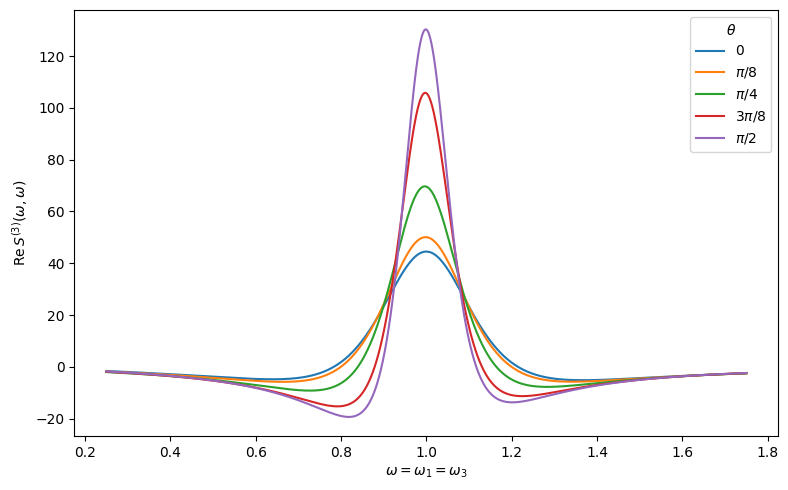

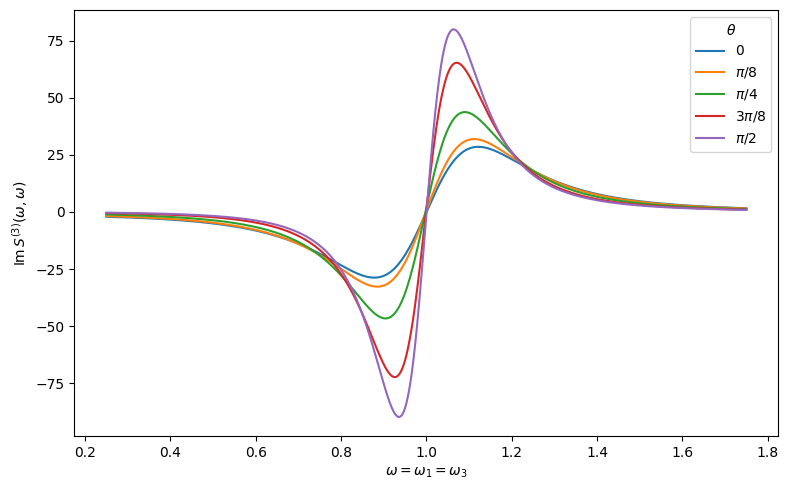

Computing sector: ALL_RWA


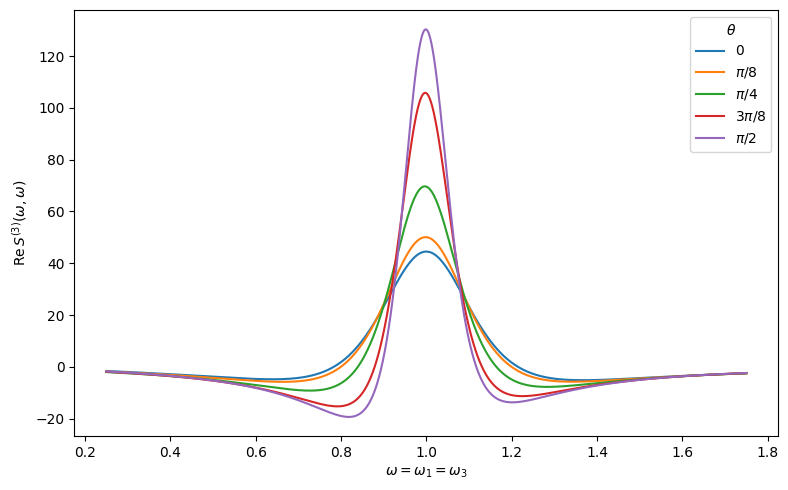

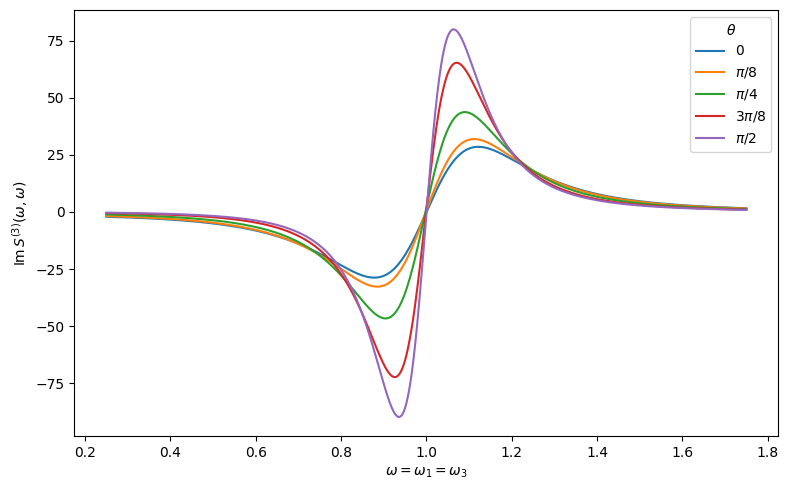

Computing sector: RP


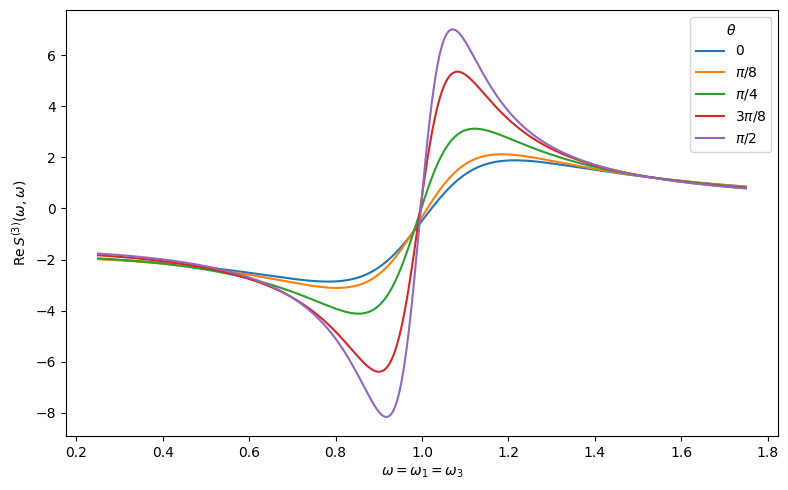

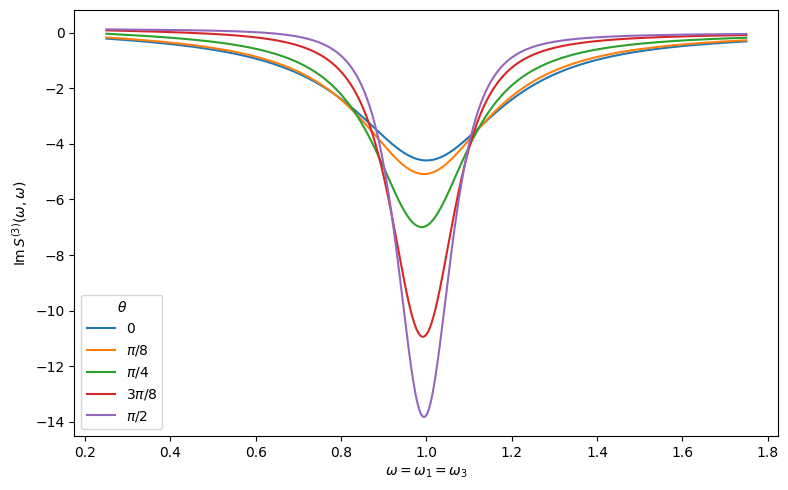

Computing sector: NRP


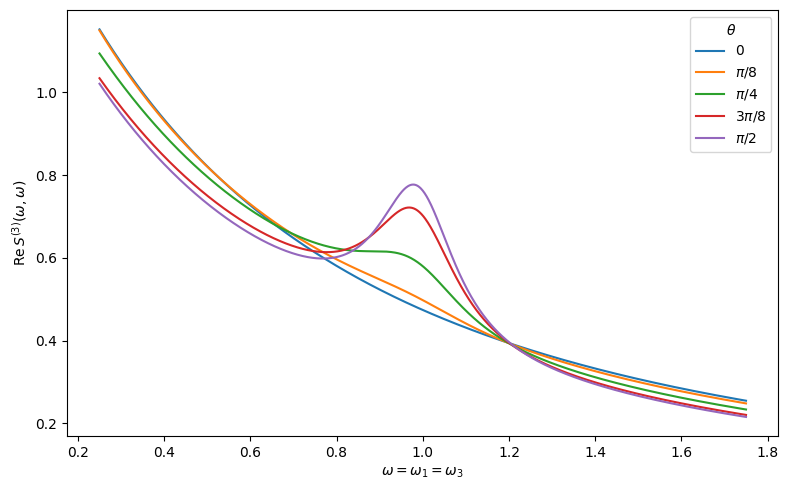

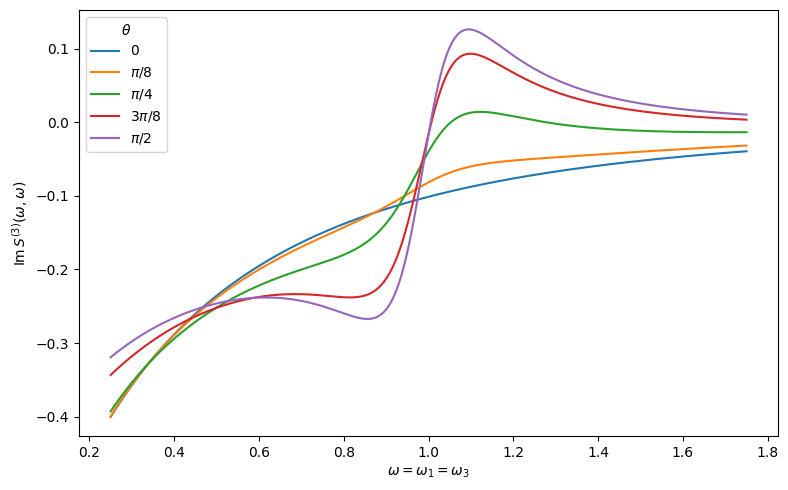

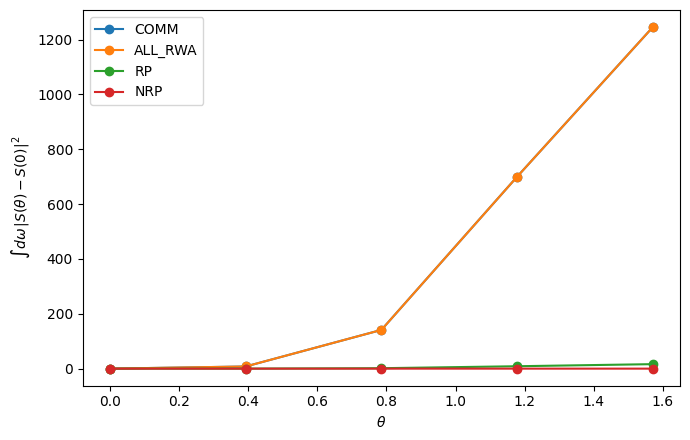

{'omegas': array([0.25  , 0.2515, 0.253 , ..., 1.747 , 1.7485, 1.75  ]),
 'theta_values': array([0.        , 0.39269908, 0.78539816, 1.17809725, 1.57079633]),
 'theta_labels': ['0', '$\\pi/8$', '$\\pi/4$', '$3\\pi/8$', '$\\pi/2$'],
 'signals_by_sector': {'COMM': array([[-1.60350399-2.0843042j , -1.61450636-2.09206638j,
          -1.62553362-2.09989933j, ..., -2.51755131+1.66279305j,
          -2.50931682+1.65364533j, -2.50111478+1.64456193j],
         [-1.80564604-1.8038342j , -1.81691583-1.81191144j,
          -1.82821805-1.82004582j, ..., -2.51962445+1.55199081j,
          -2.51111036+1.54338702j, -2.50263225+1.53484446j],
         [-2.02299786-1.10080865j, -2.03568106-1.10792644j,
          -2.04840392-1.1150884j , ..., -2.4986986 +1.28740779j,
          -2.48966736+1.28015728j, -2.48067951+1.2729597j ],
         [-1.90825362-0.48886495j, -1.92168449-0.49335142j,
          -1.93516435-0.49787434j, ..., -2.44040374+1.0300742j ,
          -2.43109113+1.02420717j, -2.42182748+1.0183838

In [ ]:
run_phase_matched_diagnostic()

In [ ]:
# ============================================================
# phase_matched_response_rwa.py
# ============================================================
#
# Frequency-domain RP/NRP/DQC decomposition for the rotated
# pointer-basis Liouvillian model.
#
# Key correction:
#   RP and NRP use different Fourier signs during the first
#   coherence interval.
#
#   RP:   G1 = G(-omega1),  G3 = G(+omega3)
#   NRP:  G1 = G(+omega1),  G3 = G(+omega3)
#   DQC:  G1 = G(+omega1),  G3 = G(+omega3)
#
# This module separates:
#   1. algebraic nested-commutator checks, and
#   2. physically phase-matched RP/NRP sector spectra.
#
# ============================================================

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from itertools import product
from numpy import kron


# ------------------------------------------------------------
# Basic two-level operators
# ------------------------------------------------------------

I2 = np.eye(2, dtype=complex)

sig_x = np.array([[0, 1],
                  [1, 0]], dtype=complex)

sig_z = np.array([[-1, 0],
                  [ 0, 1]], dtype=complex)

sig_p = np.array([[0, 0],
                  [1, 0]], dtype=complex)

sig_m = np.array([[0, 1],
                  [0, 0]], dtype=complex)

mu_plus = sig_p
mu_minus = sig_m
mu = mu_plus + mu_minus


# ------------------------------------------------------------
# Vectorization and superoperators
# ------------------------------------------------------------

def vec(rho):
    return rho.reshape(-1, order="F")


def mat(rho_vec, dim=2):
    return rho_vec.reshape((dim, dim), order="F")


def left_super(O):
    """rho -> O rho"""
    return kron(I2, O)


def right_super(O):
    """rho -> rho O"""
    return kron(O.T, I2)


def comm_super(O):
    """rho -> [O,rho]"""
    return left_super(O) - right_super(O)


def J_left(O):
    return left_super(O)


def J_right(O):
    return -right_super(O)


def J_side(side, O):
    side = side.upper()
    if side == "L":
        return J_left(O)
    if side == "R":
        return J_right(O)
    raise ValueError("side must be 'L' or 'R'")


# ------------------------------------------------------------
# RWA optical components
# ------------------------------------------------------------

FIELD_TO_MU = {
    "+": mu_minus,   # E^(+) couples to mu^-
    "-": mu_plus,    # E^(-) couples to mu^+
}

FIELD_PHASE_SIGN = {
    "+": +1,
    "-": -1,
}


def mu_for_field(field):
    if field not in FIELD_TO_MU:
        raise ValueError("field must be '+' or '-'")
    return FIELD_TO_MU[field]


def phase_sign_for_field(field):
    if field not in FIELD_PHASE_SIGN:
        raise ValueError("field must be '+' or '-'")
    return FIELD_PHASE_SIGN[field]


def interaction_super(side, field):
    return J_side(side, mu_for_field(field))


# ------------------------------------------------------------
# Liouvillian model
# ------------------------------------------------------------

def liouvillian(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02):
    H = 0.5 * w0 * sig_z

    L = -1j * (left_super(H) - right_super(H))

    A = np.cos(theta) * sig_z + np.sin(theta) * sig_x
    C = np.sqrt(gamma_phi) * A
    CdC = C.conj().T @ C

    L += (
        kron(C.conj(), C)
        - 0.5 * kron(I2, CdC)
        - 0.5 * kron(CdC.T, I2)
    )

    if gamma1 > 0:
        C1 = np.sqrt(gamma1) * sig_m
        CdC1 = C1.conj().T @ C1

        L += (
            kron(C1.conj(), C1)
            - 0.5 * kron(I2, CdC1)
            - 0.5 * kron(CdC1.T, I2)
        )

    return L


def G_freq(L, omega, eta=1e-3):
    n = L.shape[0]
    return -np.linalg.inv(L + (1j * omega - eta) * np.eye(n))


def rho_initial_ground():
    return vec(np.array([[1, 0],
                         [0, 0]], dtype=complex))


# ------------------------------------------------------------
# Pathway bookkeeping
# ------------------------------------------------------------

def make_pathway(sides, fields):
    if len(sides) != 3 or len(fields) != 3:
        raise ValueError("sides and fields must have length 3")
    return tuple((s.upper(), f) for s, f in zip(sides, fields))


def pathway_phase_signature(pathway):
    return tuple(phase_sign_for_field(field) for side, field in pathway)


def pathway_label(pathway):
    return "".join([f"{side}{field}" for side, field in pathway])


def all_rwa_pathways():
    paths = []
    for sides in product(["L", "R"], repeat=3):
        for fields in product(["+", "-"], repeat=3):
            paths.append(make_pathway(sides, fields))
    return paths


SECTOR_PHASES = {
    "RP":  (-1, +1, +1),
    "NRP": (+1, -1, +1),
    "DQC": (+1, +1, -1),
}


def get_sector_pathways(sector):
    sector = sector.upper()

    if sector == "ALL_RWA":
        return all_rwa_pathways()

    if sector not in SECTOR_PHASES:
        raise ValueError("sector must be RP, NRP, DQC, or ALL_RWA")

    target = SECTOR_PHASES[sector]

    return [
        p for p in all_rwa_pathways()
        if pathway_phase_signature(p) == target
    ]


def omega1_sign_for_sector(sector):
    """
    Fourier sign convention for the first coherence interval.

    Physical 2D spectroscopy convention:
        RP   uses exp(-i omega1 t1)  -> G(-omega1)
        NRP  uses exp(+i omega1 t1)  -> G(+omega1)
        DQC  uses exp(+i omega1 t1)  -> G(+omega1)

    ALL_RWA is not a physical phase-matched spectrum unless a specific
    Fourier convention is chosen. For algebraic checks use
    signal_point_diag_all_rwa_algebraic().
    """
    sector = sector.upper()

    if sector == "RP":
        return -1

    if sector in ["NRP", "DQC"]:
        return +1

    raise ValueError("omega1 sign is defined only for RP, NRP, DQC")


def print_sector_summary(max_print=8):
    for sector in ["RP", "NRP", "DQC", "ALL_RWA"]:
        paths = get_sector_pathways(sector)
        print(f"\n{sector}: {len(paths)} pathways")

        for p in paths[:max_print]:
            print(f"  {pathway_label(p):8s}  phase {pathway_phase_signature(p)}")

        if len(paths) > max_print:
            print(f"  ... {len(paths)-max_print} more")


# ------------------------------------------------------------
# Core response functions
# ------------------------------------------------------------

def signal_point_comm_plus(theta, omega,
                           tau2=1.0,
                           w0=1.0,
                           gamma_phi=0.1,
                           gamma1=0.02,
                           eta=1e-3):
    """
    Original nested-commutator diagonal response with G1=G(+omega),
    G3=G(+omega).

    This is the historical diagnostic used in the earlier code.
    """
    L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=theta, gamma1=gamma1)

    J = comm_super(mu)
    rho0 = rho_initial_ground()

    G = G_freq(L, omega, eta=eta)
    U2 = scipy.linalg.expm(L * tau2)

    rho_vec = G @ J @ U2 @ J @ G @ J @ rho0
    rho = mat(rho_vec)

    return np.trace(mu @ rho)


def signal_point_pathway(theta, omega1, omega3, pathway,
                         omega1_sign=+1,
                         tau2=1.0,
                         w0=1.0,
                         gamma_phi=0.1,
                         gamma1=0.02,
                         eta=1e-3,
                         detection="full"):
    """
    RWA-resolved pathway response.

    pathway:
        ((side1, field1), (side2, field2), (side3, field3))

    omega1_sign:
        RP  -> -1
        NRP -> +1
        DQC -> +1
    """
    L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=theta, gamma1=gamma1)

    J1 = interaction_super(*pathway[0])
    J2 = interaction_super(*pathway[1])
    J3 = interaction_super(*pathway[2])

    G1 = G_freq(L, omega1_sign * omega1, eta=eta)
    G3 = G_freq(L, omega3, eta=eta)
    U2 = scipy.linalg.expm(L * tau2)

    rho0 = rho_initial_ground()

    rho_vec = G3 @ J3 @ U2 @ J2 @ G1 @ J1 @ rho0
    rho = mat(rho_vec)

    if detection == "full":
        Odet = mu
    elif detection == "+":
        Odet = mu_plus
    elif detection == "-":
        Odet = mu_minus
    else:
        raise ValueError("detection must be 'full', '+', or '-'")

    return np.trace(Odet @ rho)


def signal_point_sector(theta, omega1, omega3, sector,
                        tau2=1.0,
                        w0=1.0,
                        gamma_phi=0.1,
                        gamma1=0.02,
                        eta=1e-3,
                        detection="full"):
    """
    Physical phase-matched sector response.

    sector:
        RP, NRP, DQC
    """
    sector = sector.upper()

    if sector not in ["RP", "NRP", "DQC"]:
        raise ValueError("physical sector must be RP, NRP, or DQC")

    s1 = omega1_sign_for_sector(sector)

    total = 0.0 + 0.0j

    for pathway in get_sector_pathways(sector):
        total += signal_point_pathway(
            theta, omega1, omega3, pathway,
            omega1_sign=s1,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
        )

    return total


def signal_point_diag(theta, omega, sector="COMM_PLUS",
                      tau2=1.0,
                      w0=1.0,
                      gamma_phi=0.1,
                      gamma1=0.02,
                      eta=1e-3,
                      detection="full"):
    """
    Diagonal response S(omega1=omega3=omega).

    sector options:
        COMM_PLUS : original nested commutator with G1=G(+omega)
        RP        : physical rephasing diagonal, G1=G(-omega)
        NRP       : physical nonrephasing diagonal, G1=G(+omega)
        DQC       : physical DQC diagonal, G1=G(+omega)
    """
    sector = sector.upper()

    if sector in ["COMM", "COMM_PLUS"]:
        return signal_point_comm_plus(
            theta, omega,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
        )

    if sector in ["RP", "NRP", "DQC"]:
        return signal_point_sector(
            theta, omega, omega, sector,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
        )

    raise ValueError("sector must be COMM_PLUS, RP, NRP, or DQC")


# ------------------------------------------------------------
# Algebraic consistency check
# ------------------------------------------------------------

def signal_point_all_rwa_algebraic(theta, omega,
                                   tau2=1.0,
                                   w0=1.0,
                                   gamma_phi=0.1,
                                   gamma1=0.02,
                                   eta=1e-3,
                                   detection="full"):
    """
    Algebraic RWA pathway sum using the same +omega convention for G1
    and G3.

    This is for validating that the RWA-resolved pathway bookkeeping
    reproduces the original nested-commutator response.

    It is not a physical phase-matched 2D spectrum.
    """
    total = 0.0 + 0.0j

    for pathway in get_sector_pathways("ALL_RWA"):
        total += signal_point_pathway(
            theta, omega, omega, pathway,
            omega1_sign=+1,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
        )

    return total


def check_comm_vs_all_rwa(theta=np.pi/4,
                          omega=1.0,
                          tau2=1.0,
                          w0=1.0,
                          gamma_phi=0.1,
                          gamma1=0.02,
                          eta=1e-3,
                          verbose=True):
    S_comm = signal_point_comm_plus(
        theta, omega,
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
    )

    S_all = signal_point_all_rwa_algebraic(
        theta, omega,
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
        detection="full",
    )

    mismatch = np.abs(S_comm - S_all) / max(np.abs(S_comm), 1e-14)

    if verbose:
        print("COMM_PLUS response:    ", S_comm)
        print("ALL_RWA algebraic sum:", S_all)
        print("relative mismatch:    ", mismatch)

    return mismatch, S_comm, S_all


# ------------------------------------------------------------
# Sweeps and diagnostics
# ------------------------------------------------------------

def signal_sweep(theta_values, omegas, sector="RP",
                 tau2=1.0,
                 w0=1.0,
                 gamma_phi=0.1,
                 gamma1=0.02,
                 eta=1e-3,
                 detection="full"):
    out = []

    for th in theta_values:
        out.append(np.array([
            signal_point_diag(
                th, om, sector=sector,
                tau2=tau2,
                w0=w0,
                gamma_phi=gamma_phi,
                gamma1=gamma1,
                eta=eta,
                detection=detection,
            )
            for om in omegas
        ]))

    return np.array(out)


def deformation_metric(signals, omegas):
    ref = signals[0]
    return np.array([
        np.trapezoid(np.abs(S - ref)**2, omegas)
        for S in signals
    ])


def normalized_deformation_metric(signals, omegas):
    ref = signals[0]
    norm_ref = np.trapezoid(np.abs(ref)**2, omegas)

    return np.array([
        np.trapezoid(np.abs(S - ref)**2, omegas) / max(norm_ref, 1e-14)
        for S in signals
    ])


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------

def plot_sector_sweep(omegas, signals, theta_labels,
                      sector="RP",
                      component="imag",
                      filename=None):
    plt.figure(figsize=(8, 5))

    for S, lab in zip(signals, theta_labels):
        if component == "real":
            y = np.real(S)
            ylabel = rf"$\mathrm{{Re}}\,S_{{\rm {sector}}}^{{(3)}}(\omega,\omega)$"
        elif component == "imag":
            y = np.imag(S)
            ylabel = rf"$\mathrm{{Im}}\,S_{{\rm {sector}}}^{{(3)}}(\omega,\omega)$"
        elif component == "abs":
            y = np.abs(S)
            ylabel = rf"$|S_{{\rm {sector}}}^{{(3)}}(\omega,\omega)|$"
        else:
            raise ValueError("component must be real, imag, or abs")

        plt.plot(omegas, y, label=lab)

    plt.xlabel(r"$\omega = \omega_1 = \omega_3$")
    plt.ylabel(ylabel)
    plt.legend(title=r"$\theta$")
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=200)

    plt.show()


def plot_deformation(theta_values, deformation_by_sector,
                     normalized=False,
                     filename=None):
    plt.figure(figsize=(7, 4.5))

    for sector, deform in deformation_by_sector.items():
        plt.plot(theta_values, deform, marker="o", label=sector)

    plt.xlabel(r"$\theta$")

    if normalized:
        plt.ylabel(r"$\int d\omega\, |S(\theta)-S(0)|^2 / \int d\omega\, |S(0)|^2$")
    else:
        plt.ylabel(r"$\int d\omega\, |S(\theta)-S(0)|^2$")

    plt.legend()
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=200)

    plt.show()


# ------------------------------------------------------------
# Driver
# ------------------------------------------------------------

def run_phase_matched_diagnostic():
    w0 = 1.0
    omega0 = 1.0
    gamma_phi = 0.1
    gamma1 = 0.02
    tau2 = 1.0
    eta = 1e-3

    delta = 0.75
    omegas = np.linspace(omega0 - delta, omega0 + delta, 1001)

    theta_values = np.array([
        0,
        np.pi / 8,
        np.pi / 4,
        3*np.pi / 8,
        np.pi / 2,
    ])

    theta_labels = [
        "0",
        r"$\pi/8$",
        r"$\pi/4$",
        r"$3\pi/8$",
        r"$\pi/2$",
    ]

    print_sector_summary()

    print("\nAlgebraic validation: COMM_PLUS vs ALL_RWA")
    check_comm_vs_all_rwa(
        theta=np.pi/4,
        omega=omega0,
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
        verbose=True,
    )

    sectors = ["RP", "NRP", "DQC"]

    signals_by_sector = {}

    for sector in sectors:
        print(f"\nComputing physical sector: {sector}")

        signals_by_sector[sector] = signal_sweep(
            theta_values,
            omegas,
            sector=sector,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection="full",
        )

        plot_sector_sweep(
            omegas,
            signals_by_sector[sector],
            theta_labels,
            sector=sector,
            component="real",
            filename=f"diag_theta_{sector}_real_corrected.png",
        )

        plot_sector_sweep(
            omegas,
            signals_by_sector[sector],
            theta_labels,
            sector=sector,
            component="imag",
            filename=f"diag_theta_{sector}_imag_corrected.png",
        )

    deformation_by_sector = {
        sector: deformation_metric(signals, omegas)
        for sector, signals in signals_by_sector.items()
    }

    normalized_deformation_by_sector = {
        sector: normalized_deformation_metric(signals, omegas)
        for sector, signals in signals_by_sector.items()
    }

    plot_deformation(
        theta_values,
        deformation_by_sector,
        normalized=False,
        filename="phase_matched_sector_deformation_corrected.png",
    )

    plot_deformation(
        theta_values,
        normalized_deformation_by_sector,
        normalized=True,
        filename="phase_matched_sector_deformation_normalized_corrected.png",
    )

    print("\nSector deformation summary")
    print("-" * 50)

    for sector in sectors:
        deform = deformation_by_sector[sector]
        ndeform = normalized_deformation_by_sector[sector]

        print(
            f"{sector:4s}  "
            f"absolute final = {deform[-1]:12.6e}   "
            f"normalized final = {ndeform[-1]:12.6e}"
        )

    return {
        "omegas": omegas,
        "theta_values": theta_values,
        "theta_labels": theta_labels,
        "signals_by_sector": signals_by_sector,
        "deformation_by_sector": deformation_by_sector,
        "normalized_deformation_by_sector": normalized_deformation_by_sector,
    }


RP: 8 pathways
  L-L+L+    phase (-1, 1, 1)
  L-L+R+    phase (-1, 1, 1)
  L-R+L+    phase (-1, 1, 1)
  L-R+R+    phase (-1, 1, 1)
  R-L+L+    phase (-1, 1, 1)
  R-L+R+    phase (-1, 1, 1)
  R-R+L+    phase (-1, 1, 1)
  R-R+R+    phase (-1, 1, 1)

NRP: 8 pathways
  L+L-L+    phase (1, -1, 1)
  L+L-R+    phase (1, -1, 1)
  L+R-L+    phase (1, -1, 1)
  L+R-R+    phase (1, -1, 1)
  R+L-L+    phase (1, -1, 1)
  R+L-R+    phase (1, -1, 1)
  R+R-L+    phase (1, -1, 1)
  R+R-R+    phase (1, -1, 1)

DQC: 8 pathways
  L+L+L-    phase (1, 1, -1)
  L+L+R-    phase (1, 1, -1)
  L+R+L-    phase (1, 1, -1)
  L+R+R-    phase (1, 1, -1)
  R+L+L-    phase (1, 1, -1)
  R+L+R-    phase (1, 1, -1)
  R+R+L-    phase (1, 1, -1)
  R+R+R-    phase (1, 1, -1)

ALL_RWA: 64 pathways
  L+L+L+    phase (1, 1, 1)
  L+L+L-    phase (1, 1, -1)
  L+L-L+    phase (1, -1, 1)
  L+L-L-    phase (1, -1, -1)
  L-L+L+    phase (-1, 1, 1)
  L-L+L-    phase (-1, 1, -1)
  L-L-L+    phase (-1, -1, 1)
  L-L-L-    phase (-1, -1, 

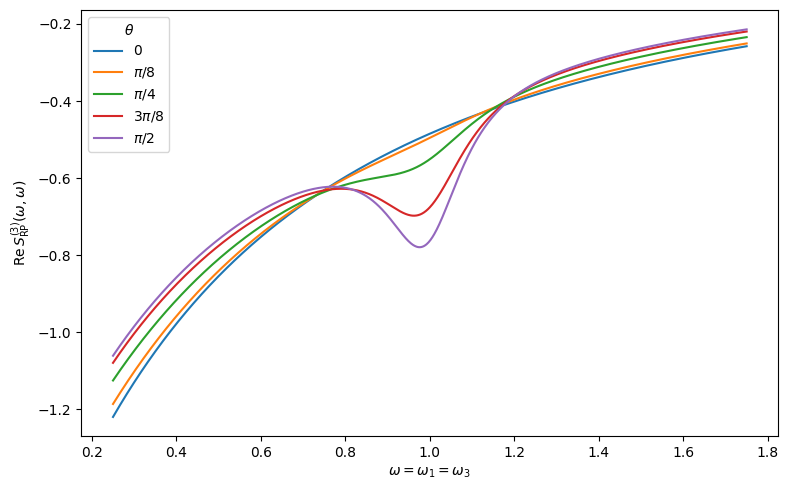

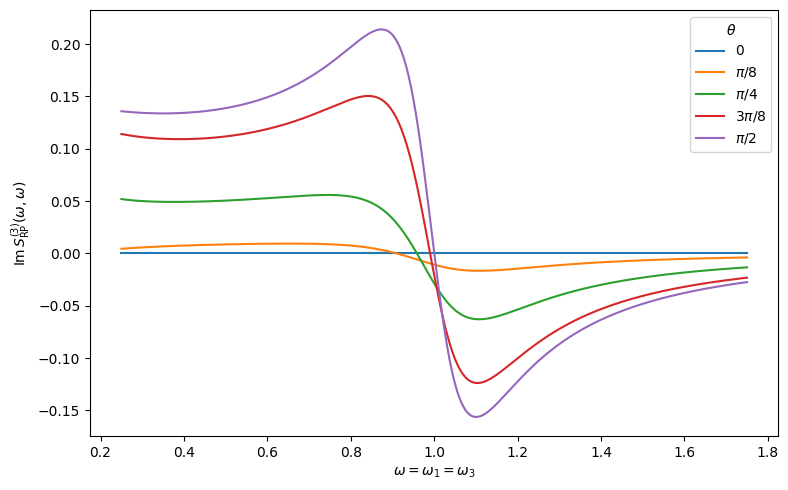


Computing physical sector: NRP


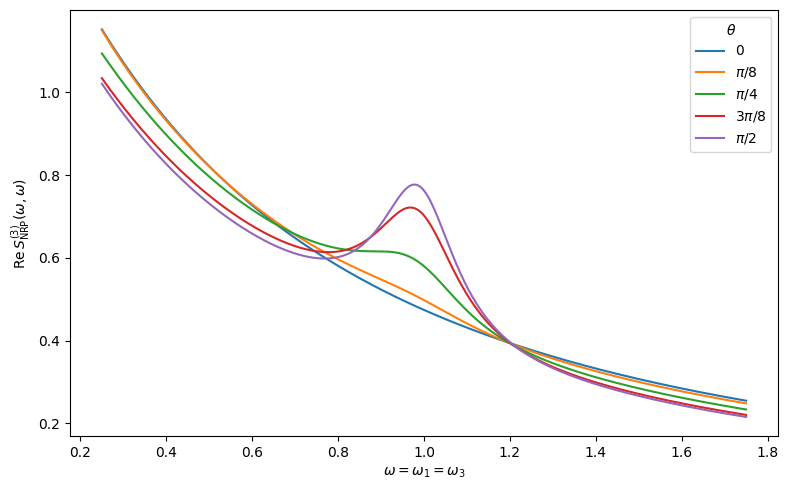

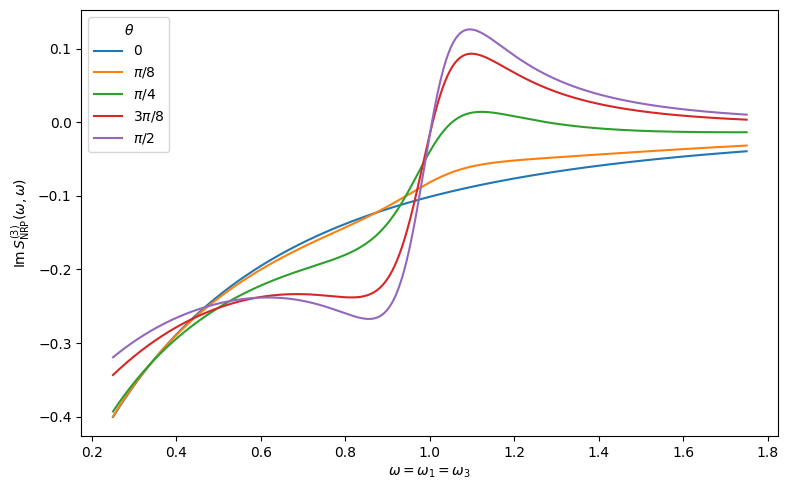


Computing physical sector: DQC


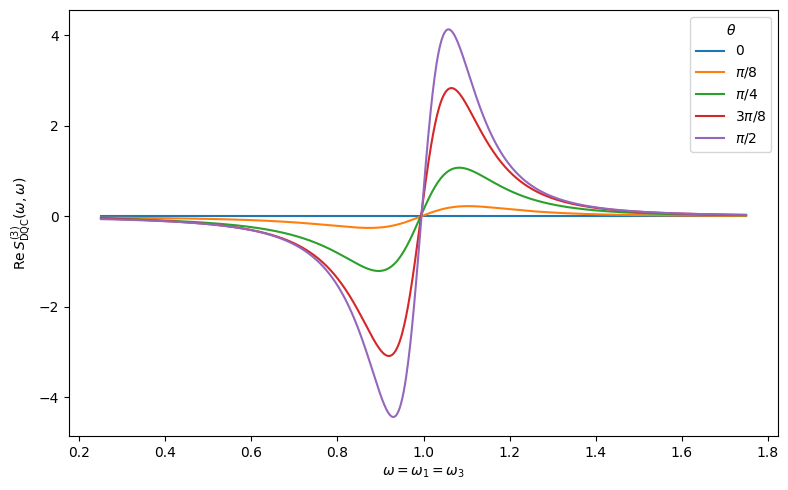

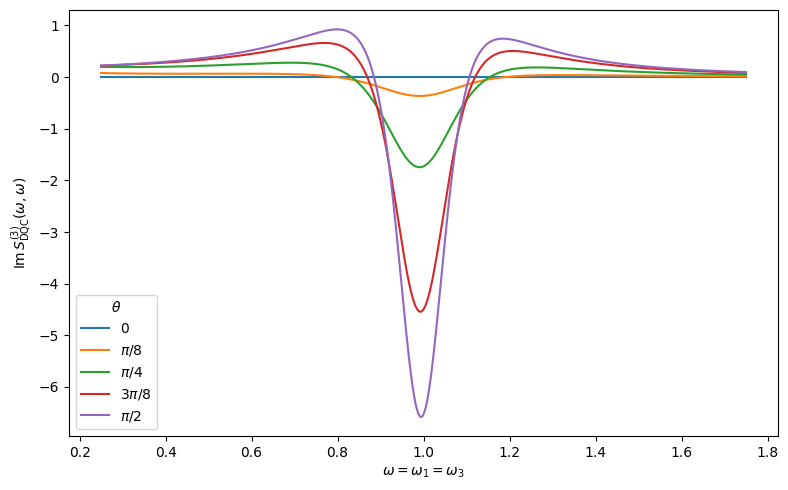

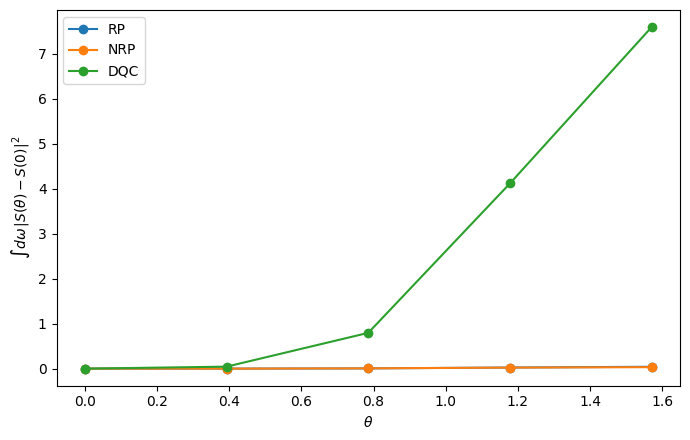

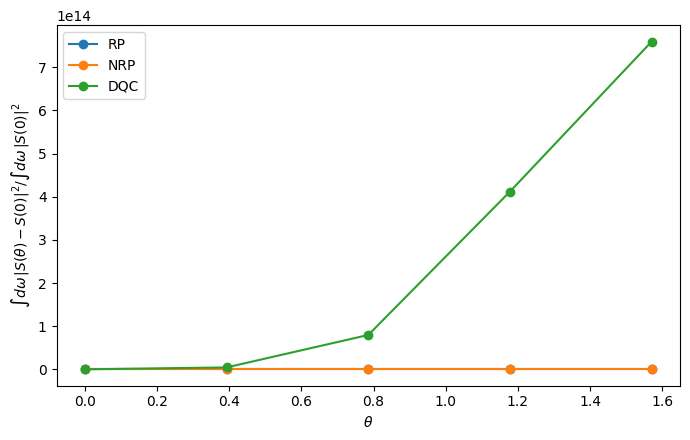


Sector deformation summary
--------------------------------------------------
RP    absolute final = 4.159219e-02   normalized final = 7.259022e-02
NRP   absolute final = 3.316013e-02   normalized final = 5.787389e-02
DQC   absolute final = 7.596931e+00   normalized final = 7.596931e+14


In [ ]:
results = run_phase_matched_diagnostic()

In [ ]:
# ============================================================
# phase_matched_response_initial_state_compare.py
# ============================================================
#
# Purpose
# -------
# Frequency-domain RP/NRP sector diagnostics for the rotated
# pointer-basis Liouvillian model, with explicit comparison of
# initial-state choices.
#
# Initial-state modes
# -------------------
# steady
#     rho0 = rho_ss(theta), the stationary state of the Liouvillian
#     used for the response calculation.
#
# ground
#     rho0 = |g><g|, the original fixed initial state.
#
# fixed_steady0
#     rho0 = rho_ss(theta=0), held fixed for all theta.
#     This separates Liouvillian transport effects from changes in
#     the stationary state.
#
# Sectors
# -------
# COMM_PLUS
#     Original full-commutator response with G1=G(+omega), G3=G(+omega).
#
# RP
#     Physical rephasing sector:
#         -k1 + k2 + k3
#         G1 = G(-omega1), G3 = G(+omega3)
#
# NRP
#     Physical nonrephasing sector:
#         +k1 - k2 + k3
#         G1 = G(+omega1), G3 = G(+omega3)
#
# DQC
#     Double-quantum sector:
#         +k1 + k2 - k3
#
# Notes
# -----
# This module is intended as a diagnostic/validation module. It is
# written for clarity rather than speed.
# ============================================================

import numpy as np
import scipy.linalg
import matplotlib.pyplot as plt
from itertools import product
from numpy import kron


# ------------------------------------------------------------
# Basic two-level operators
# ------------------------------------------------------------

I2 = np.eye(2, dtype=complex)

sig_x = np.array([[0, 1],
                  [1, 0]], dtype=complex)

sig_z = np.array([[-1, 0],
                  [ 0, 1]], dtype=complex)

sig_p = np.array([[0, 0],
                  [1, 0]], dtype=complex)

sig_m = np.array([[0, 1],
                  [0, 0]], dtype=complex)

mu_plus = sig_p
mu_minus = sig_m
mu = mu_plus + mu_minus


# ------------------------------------------------------------
# Vectorization and superoperators
# ------------------------------------------------------------

def vec(rho):
    return rho.reshape(-1, order="F")


def mat(rho_vec, dim=2):
    return rho_vec.reshape((dim, dim), order="F")


def left_super(O):
    return kron(I2, O)


def right_super(O):
    return kron(O.T, I2)


def comm_super(O):
    return left_super(O) - right_super(O)


def J_left(O):
    return left_super(O)


def J_right(O):
    return -right_super(O)


def J_side(side, O):
    side = side.upper()
    if side == "L":
        return J_left(O)
    if side == "R":
        return J_right(O)
    raise ValueError("side must be 'L' or 'R'")


# ------------------------------------------------------------
# RWA components
# ------------------------------------------------------------

FIELD_TO_MU = {
    "+": mu_minus,   # E^(+) couples to mu^-
    "-": mu_plus,    # E^(-) couples to mu^+
}

FIELD_PHASE_SIGN = {
    "+": +1,
    "-": -1,
}


def mu_for_field(field):
    if field not in FIELD_TO_MU:
        raise ValueError("field must be '+' or '-'")
    return FIELD_TO_MU[field]


def phase_sign_for_field(field):
    if field not in FIELD_PHASE_SIGN:
        raise ValueError("field must be '+' or '-'")
    return FIELD_PHASE_SIGN[field]


def interaction_super(side, field):
    return J_side(side, mu_for_field(field))


# ------------------------------------------------------------
# Liouvillian
# ------------------------------------------------------------

def liouvillian(w0=1.0, gamma_phi=0.1, theta=0.0, gamma1=0.02):
    H = 0.5 * w0 * sig_z

    L = -1j * (left_super(H) - right_super(H))

    A = np.cos(theta) * sig_z + np.sin(theta) * sig_x
    C = np.sqrt(gamma_phi) * A
    CdC = C.conj().T @ C

    L += (
        kron(C.conj(), C)
        - 0.5 * kron(I2, CdC)
        - 0.5 * kron(CdC.T, I2)
    )

    if gamma1 > 0:
        C1 = np.sqrt(gamma1) * sig_m
        CdC1 = C1.conj().T @ C1

        L += (
            kron(C1.conj(), C1)
            - 0.5 * kron(I2, CdC1)
            - 0.5 * kron(CdC1.T, I2)
        )

    return L


def G_freq(L, omega, eta=1e-3):
    n = L.shape[0]
    return -np.linalg.inv(L + (1j * omega - eta) * np.eye(n))


# ------------------------------------------------------------
# Initial states
# ------------------------------------------------------------

def rho_ground():
    rho = np.array([[1, 0],
                    [0, 0]], dtype=complex)
    return vec(rho)


def steady_state(L, dim=2):
    """
    Compute normalized stationary state:

        L rho_ss = 0,
        Tr rho_ss = 1.

    The eigenvector with eigenvalue closest to zero is used.
    """
    evals, evecs = np.linalg.eig(L)
    idx = np.argmin(np.abs(evals))

    rho_vec = evecs[:, idx]
    rho = mat(rho_vec, dim=dim)

    # Remove small numerical non-Hermiticity.
    rho = 0.5 * (rho + rho.conj().T)

    tr = np.trace(rho)

    if abs(tr) < 1e-14:
        raise RuntimeError("Steady-state eigenvector has near-zero trace.")

    rho = rho / tr

    return vec(rho)


def initial_state(L, mode="steady", L_ref=None):
    """
    Select the initial state used before the first optical interaction.

    mode:
        steady
            steady state of current L.

        ground
            fixed |g><g|.

        fixed_steady0
            steady state of reference L_ref, usually L(theta=0).
    """
    mode = mode.lower()

    if mode == "steady":
        return steady_state(L)

    if mode == "ground":
        return rho_ground()

    if mode == "fixed_steady0":
        if L_ref is None:
            raise ValueError("L_ref is required for fixed_steady0 mode")
        return steady_state(L_ref)

    raise ValueError("mode must be 'steady', 'ground', or 'fixed_steady0'")


def print_steady_state_diagnostics(theta_values=(0, np.pi/4, np.pi/2),
                                   w0=1.0,
                                   gamma_phi=0.1,
                                   gamma1=0.02):
    print("\nSteady-state diagnostics")
    print("-" * 60)

    for th in theta_values:
        L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=th, gamma1=gamma1)
        rho_vec = steady_state(L)
        rho = mat(rho_vec)

        residual = np.linalg.norm(L @ rho_vec)

        print(f"\ntheta = {th:.6f}")
        print("rho_ss =")
        print(np.real_if_close(rho))
        print("trace =", np.trace(rho))
        print("L rho residual =", residual)


# ------------------------------------------------------------
# Pathway bookkeeping
# ------------------------------------------------------------

def make_pathway(sides, fields):
    if len(sides) != 3 or len(fields) != 3:
        raise ValueError("sides and fields must have length 3")
    return tuple((s.upper(), f) for s, f in zip(sides, fields))


def pathway_phase_signature(pathway):
    return tuple(phase_sign_for_field(field) for side, field in pathway)


def pathway_label(pathway):
    return "".join([f"{side}{field}" for side, field in pathway])


def all_rwa_pathways():
    paths = []
    for sides in product(["L", "R"], repeat=3):
        for fields in product(["+", "-"], repeat=3):
            paths.append(make_pathway(sides, fields))
    return paths


SECTOR_PHASES = {
    "RP":  (-1, +1, +1),
    "NRP": (+1, -1, +1),
    "DQC": (+1, +1, -1),
}


def get_sector_pathways(sector):
    sector = sector.upper()

    if sector == "ALL_RWA":
        return all_rwa_pathways()

    if sector not in SECTOR_PHASES:
        raise ValueError("sector must be RP, NRP, DQC, or ALL_RWA")

    target = SECTOR_PHASES[sector]

    return [
        p for p in all_rwa_pathways()
        if pathway_phase_signature(p) == target
    ]


def omega1_sign_for_sector(sector):
    sector = sector.upper()

    if sector == "RP":
        return -1

    if sector in ["NRP", "DQC"]:
        return +1

    raise ValueError("omega1 sign is defined only for RP, NRP, DQC")


def print_sector_summary(max_print=8):
    print("\nPhase-matched sectors")
    print("-" * 60)

    for sector in ["RP", "NRP", "DQC", "ALL_RWA"]:
        paths = get_sector_pathways(sector)
        print(f"\n{sector}: {len(paths)} pathways")

        for p in paths[:max_print]:
            print(f"  {pathway_label(p):8s} phase {pathway_phase_signature(p)}")

        if len(paths) > max_print:
            print(f"  ... {len(paths)-max_print} more")


# ------------------------------------------------------------
# Response functions
# ------------------------------------------------------------

def signal_point_comm_plus(theta, omega,
                           tau2=1.0,
                           w0=1.0,
                           gamma_phi=0.1,
                           gamma1=0.02,
                           eta=1e-3,
                           initial="steady"):
    """
    Original full-commutator diagnostic with same-sign resolvents:

        G1 = G(+omega), G3 = G(+omega).

    This is not the physical RP/NRP decomposition.
    """
    L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=theta, gamma1=gamma1)

    L_ref = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=0.0, gamma1=gamma1)
    rho0 = initial_state(L, mode=initial, L_ref=L_ref)

    J = comm_super(mu)
    G = G_freq(L, omega, eta=eta)
    U2 = scipy.linalg.expm(L * tau2)

    rho_vec = G @ J @ U2 @ J @ G @ J @ rho0
    rho = mat(rho_vec)

    return np.trace(mu @ rho)


def signal_point_pathway(theta, omega1, omega3, pathway,
                         omega1_sign=+1,
                         tau2=1.0,
                         w0=1.0,
                         gamma_phi=0.1,
                         gamma1=0.02,
                         eta=1e-3,
                         detection="full",
                         initial="steady"):
    """
    RWA-resolved pathway response with selectable initial state.
    """
    L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=theta, gamma1=gamma1)
    L_ref = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=0.0, gamma1=gamma1)

    rho0 = initial_state(L, mode=initial, L_ref=L_ref)

    J1 = interaction_super(*pathway[0])
    J2 = interaction_super(*pathway[1])
    J3 = interaction_super(*pathway[2])

    G1 = G_freq(L, omega1_sign * omega1, eta=eta)
    G3 = G_freq(L, omega3, eta=eta)
    U2 = scipy.linalg.expm(L * tau2)

    rho_vec = G3 @ J3 @ U2 @ J2 @ G1 @ J1 @ rho0
    rho = mat(rho_vec)

    if detection == "full":
        Odet = mu
    elif detection == "+":
        Odet = mu_plus
    elif detection == "-":
        Odet = mu_minus
    else:
        raise ValueError("detection must be 'full', '+', or '-'")

    return np.trace(Odet @ rho)


def signal_point_sector(theta, omega1, omega3, sector,
                        tau2=1.0,
                        w0=1.0,
                        gamma_phi=0.1,
                        gamma1=0.02,
                        eta=1e-3,
                        detection="full",
                        initial="steady"):
    sector = sector.upper()

    if sector not in ["RP", "NRP", "DQC"]:
        raise ValueError("physical sector must be RP, NRP, or DQC")

    s1 = omega1_sign_for_sector(sector)

    total = 0.0 + 0.0j

    for pathway in get_sector_pathways(sector):
        total += signal_point_pathway(
            theta, omega1, omega3, pathway,
            omega1_sign=s1,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
            initial=initial,
        )

    return total


def signal_point_diag(theta, omega, sector="RP",
                      tau2=1.0,
                      w0=1.0,
                      gamma_phi=0.1,
                      gamma1=0.02,
                      eta=1e-3,
                      detection="full",
                      initial="steady"):
    sector = sector.upper()

    if sector in ["COMM", "COMM_PLUS"]:
        return signal_point_comm_plus(
            theta, omega,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            initial=initial,
        )

    if sector in ["RP", "NRP", "DQC"]:
        return signal_point_sector(
            theta, omega, omega, sector,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
            initial=initial,
        )

    raise ValueError("sector must be COMM_PLUS, RP, NRP, or DQC")





# ------------------------------------------------------------
# Algebraic validation
# ------------------------------------------------------------

def signal_point_all_rwa_algebraic(theta, omega,
                                   tau2=1.0,
                                   w0=1.0,
                                   gamma_phi=0.1,
                                   gamma1=0.02,
                                   eta=1e-3,
                                   detection="full",
                                   initial="steady"):
    """
    Algebraic RWA sum with G1=G(+omega), G3=G(+omega).

    Used only to validate commutator/pathway bookkeeping.
    """
    total = 0.0 + 0.0j

    for pathway in get_sector_pathways("ALL_RWA"):
        total += signal_point_pathway(
            theta, omega, omega, pathway,
            omega1_sign=+1,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
            initial=initial,
        )

    return total


def check_comm_vs_all_rwa(theta=np.pi/4,
                          omega=1.0,
                          tau2=1.0,
                          w0=1.0,
                          gamma_phi=0.1,
                          gamma1=0.02,
                          eta=1e-3,
                          initial="steady",
                          verbose=True):
    S_comm = signal_point_comm_plus(
        theta, omega,
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
        initial=initial,
    )

    S_all = signal_point_all_rwa_algebraic(
        theta, omega,
        tau2=tau2,
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
        eta=eta,
        detection="full",
        initial=initial,
    )

    mismatch = np.abs(S_comm - S_all) / max(np.abs(S_comm), 1e-14)

    if verbose:
        print(f"\nAlgebraic validation, initial={initial}")
        print("COMM_PLUS response:    ", S_comm)
        print("ALL_RWA algebraic sum:", S_all)
        print("relative mismatch:    ", mismatch)

    return mismatch, S_comm, S_all


# ------------------------------------------------------------
# Sweeps and metrics
# ------------------------------------------------------------

def signal_sweep(theta_values, omegas, sector="RP",
                 tau2=1.0,
                 w0=1.0,
                 gamma_phi=0.1,
                 gamma1=0.02,
                 eta=1e-3,
                 detection="full",
                 initial="steady"):
    out = []

    for th in theta_values:
        out.append(np.array([
            signal_point_diag(
                th, om, sector=sector,
                tau2=tau2,
                w0=w0,
                gamma_phi=gamma_phi,
                gamma1=gamma1,
                eta=eta,
                detection=detection,
                initial=initial,
            )
            for om in omegas
        ]))

    return np.array(out)


def deformation_metric(signals, omegas):
    ref = signals[0]

    return np.array([
        np.trapezoid(np.abs(S - ref)**2, omegas)
        for S in signals
    ])


def normalized_deformation_metric(signals, omegas):
    ref = signals[0]
    norm_ref = np.trapezoid(np.abs(ref)**2, omegas)

    return np.array([
        np.trapezoid(np.abs(S - ref)**2, omegas) / max(norm_ref, 1e-14)
        for S in signals
    ])


# ------------------------------------------------------------
# Pathway-level diagnostic
# ------------------------------------------------------------

def pathway_contribution_table(theta=0.0,
                               omega=1.0,
                               sector="RP",
                               tau2=1.0,
                               w0=1.0,
                               gamma_phi=0.1,
                               gamma1=0.02,
                               eta=1e-3,
                               detection="full",
                               initial="steady",
                               cutoff=1e-10):
    sector = sector.upper()
    omega1_sign = omega1_sign_for_sector(sector)

    rows = []

    for pathway in get_sector_pathways(sector):
        val = signal_point_pathway(
            theta, omega, omega, pathway,
            omega1_sign=omega1_sign,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            detection=detection,
            initial=initial,
        )

        if abs(val) > cutoff:
            rows.append((pathway_label(pathway), pathway_phase_signature(pathway), val))

    print(f"\nPathway table: sector={sector}, theta={theta}, detection={detection}, initial={initial}")
    print("-" * 80)

    for label, sig, val in rows:
        print(f"{label:8s} {sig}  {val.real:+.6e} {val.imag:+.6e}j")

    print("nonzero pathways:", len(rows))

    return rows


# ------------------------------------------------------------
# Plotting
# ------------------------------------------------------------

def plot_sector_sweep(omegas, signals, theta_labels,
                      sector="RP",
                      component="imag",
                      initial="steady",
                      filename=None):
    plt.figure(figsize=(8, 5))

    for S, lab in zip(signals, theta_labels):
        if component == "real":
            y = np.real(S)
            ylabel = rf"$\mathrm{{Re}}\,S_{{\rm {sector}}}^{{(3)}}(\omega,\omega)$"
        elif component == "imag":
            y = np.imag(S)
            ylabel = rf"$\mathrm{{Im}}\,S_{{\rm {sector}}}^{{(3)}}(\omega,\omega)$"
        elif component == "abs":
            y = np.abs(S)
            ylabel = rf"$|S_{{\rm {sector}}}^{{(3)}}(\omega,\omega)|$"
        else:
            raise ValueError("component must be real, imag, or abs")

        plt.plot(omegas, y, label=lab)

    plt.xlabel(r"$\omega = \omega_1 = \omega_3$")
    plt.ylabel(ylabel)
    plt.title(f"{sector}, initial={initial}")
    plt.legend(title=r"$\theta$")
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=200)

    plt.show()


def plot_deformation(theta_values, deformation_by_label,
                     normalized=False,
                     filename=None):
    plt.figure(figsize=(7, 4.5))

    for label, deform in deformation_by_label.items():
        plt.plot(theta_values, deform, marker="o", label=label)

    plt.xlabel(r"$\theta$")

    if normalized:
        plt.ylabel(r"$\int d\omega\, |S(\theta)-S(0)|^2 / \int d\omega\, |S(0)|^2$")
    else:
        plt.ylabel(r"$\int d\omega\, |S(\theta)-S(0)|^2$")

    plt.legend()
    plt.tight_layout()

    if filename:
        plt.savefig(filename, dpi=200)

    plt.show()


# ------------------------------------------------------------
# Driver
# ------------------------------------------------------------

def run_initial_state_comparison():
    w0 = 1.0
    omega0 = 1.0
    gamma_phi = 0.1
    gamma1 = 0.02
    tau2 = 1.0
    eta = 1e-3

    delta = 0.75
    omegas = np.linspace(omega0 - delta, omega0 + delta, 1001)

    theta_values = np.array([
        0,
        np.pi / 8,
        np.pi / 4,
        3*np.pi / 8,
        np.pi / 2,
    ])

    theta_labels = [
        "0",
        r"$\pi/8$",
        r"$\pi/4$",
        r"$3\pi/8$",
        r"$\pi/2$",
    ]

    initial_modes = ["steady", "fixed_steady0", "ground"]
    sectors = ["RP", "NRP"]

    print_sector_summary()
    print_steady_state_diagnostics(
        theta_values=(0, np.pi/4, np.pi/2),
        w0=w0,
        gamma_phi=gamma_phi,
        gamma1=gamma1,
    )

    for initial in initial_modes:
        check_comm_vs_all_rwa(
            theta=np.pi/4,
            omega=omega0,
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
            initial=initial,
            verbose=True,
        )

    results = {}

    for initial in initial_modes:
        for sector in sectors:
            label = f"{sector}_{initial}"

            print(f"\nComputing {label}")

            signals = signal_sweep(
                theta_values,
                omegas,
                sector=sector,
                tau2=tau2,
                w0=w0,
                gamma_phi=gamma_phi,
                gamma1=gamma1,
                eta=eta,
                detection="full",
                initial=initial,
            )

            results[label] = {
                "signals": signals,
                "deformation": deformation_metric(signals, omegas),
                "normalized_deformation": normalized_deformation_metric(signals, omegas),
            }

            plot_sector_sweep(
                omegas,
                signals,
                theta_labels,
                sector=sector,
                component="real",
                initial=initial,
                filename=f"diag_theta_{sector}_{initial}_real.png",
            )

            plot_sector_sweep(
                omegas,
                signals,
                theta_labels,
                sector=sector,
                component="imag",
                initial=initial,
                filename=f"diag_theta_{sector}_{initial}_imag.png",
            )

    deformation_by_label = {
        label: data["deformation"]
        for label, data in results.items()
    }

    normalized_deformation_by_label = {
        label: data["normalized_deformation"]
        for label, data in results.items()
    }

    plot_deformation(
        theta_values,
        deformation_by_label,
        normalized=False,
        filename="initial_state_sector_deformation_absolute.png",
    )

    plot_deformation(
        theta_values,
        normalized_deformation_by_label,
        normalized=True,
        filename="initial_state_sector_deformation_normalized.png",
    )

    print("\nFinal deformation summary")
    print("-" * 80)

    for label, data in results.items():
        print(
            f"{label:18s} "
            f"absolute final = {data['deformation'][-1]:12.6e}   "
            f"normalized final = {data['normalized_deformation'][-1]:12.6e}"
        )

    return {
        "omegas": omegas,
        "theta_values": theta_values,
        "theta_labels": theta_labels,
        "results": results,
    }


Phase-matched sectors
------------------------------------------------------------

RP: 8 pathways
  L-L+L+   phase (-1, 1, 1)
  L-L+R+   phase (-1, 1, 1)
  L-R+L+   phase (-1, 1, 1)
  L-R+R+   phase (-1, 1, 1)
  R-L+L+   phase (-1, 1, 1)
  R-L+R+   phase (-1, 1, 1)
  R-R+L+   phase (-1, 1, 1)
  R-R+R+   phase (-1, 1, 1)

NRP: 8 pathways
  L+L-L+   phase (1, -1, 1)
  L+L-R+   phase (1, -1, 1)
  L+R-L+   phase (1, -1, 1)
  L+R-R+   phase (1, -1, 1)
  R+L-L+   phase (1, -1, 1)
  R+L-R+   phase (1, -1, 1)
  R+R-L+   phase (1, -1, 1)
  R+R-R+   phase (1, -1, 1)

DQC: 8 pathways
  L+L+L-   phase (1, 1, -1)
  L+L+R-   phase (1, 1, -1)
  L+R+L-   phase (1, 1, -1)
  L+R+R-   phase (1, 1, -1)
  R+L+L-   phase (1, 1, -1)
  R+L+R-   phase (1, 1, -1)
  R+R+L-   phase (1, 1, -1)
  R+R+R-   phase (1, 1, -1)

ALL_RWA: 64 pathways
  L+L+L+   phase (1, 1, 1)
  L+L+L-   phase (1, 1, -1)
  L+L-L+   phase (1, -1, 1)
  L+L-L-   phase (1, -1, -1)
  L-L+L+   phase (-1, 1, 1)
  L-L+L-   phase (-1, 1, -1)
  L

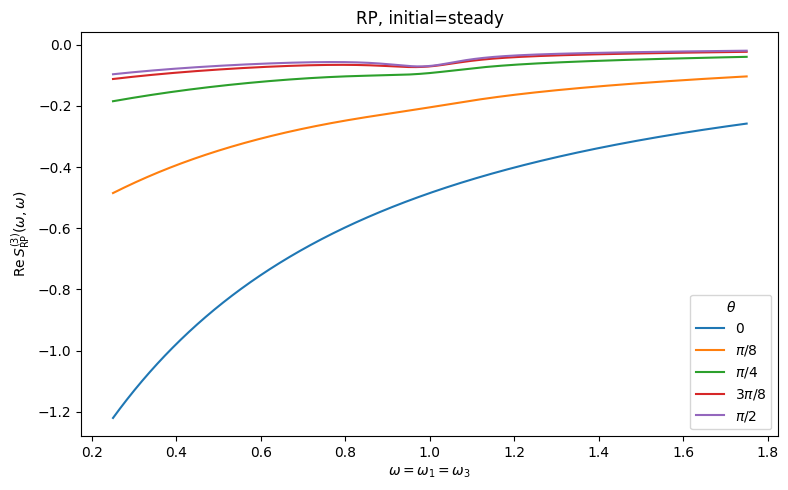

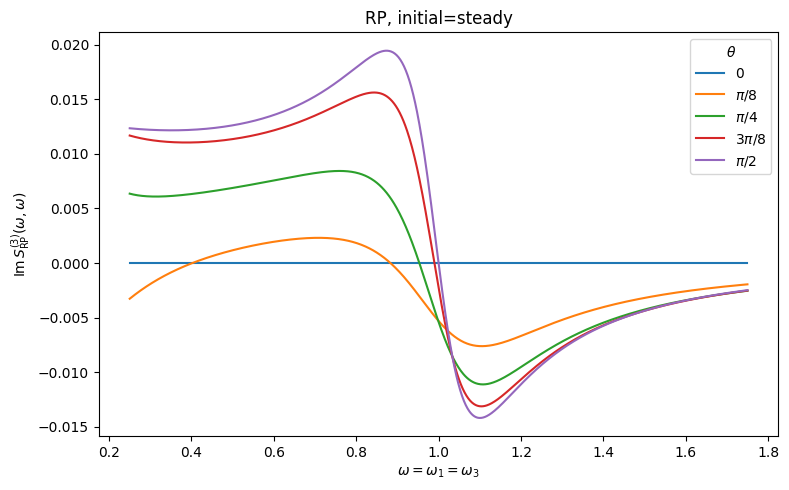


Computing NRP_steady


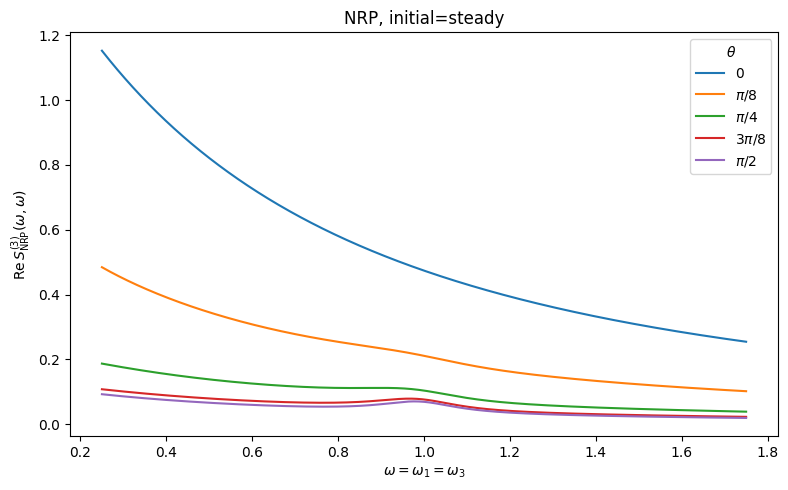

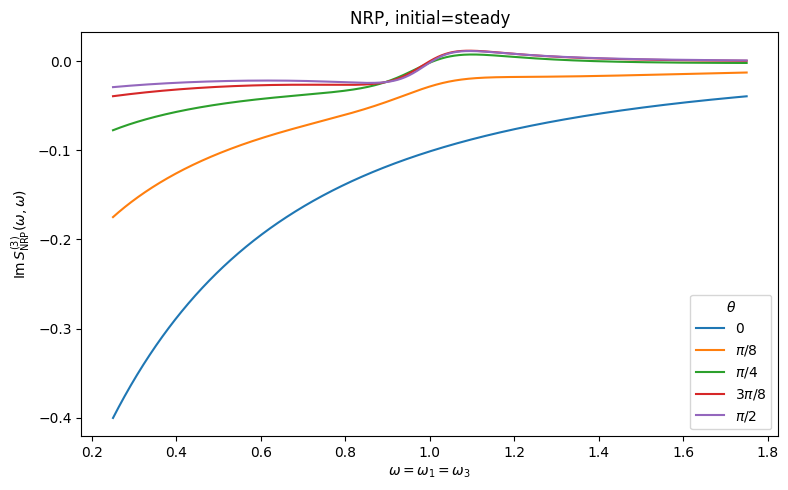


Computing RP_fixed_steady0


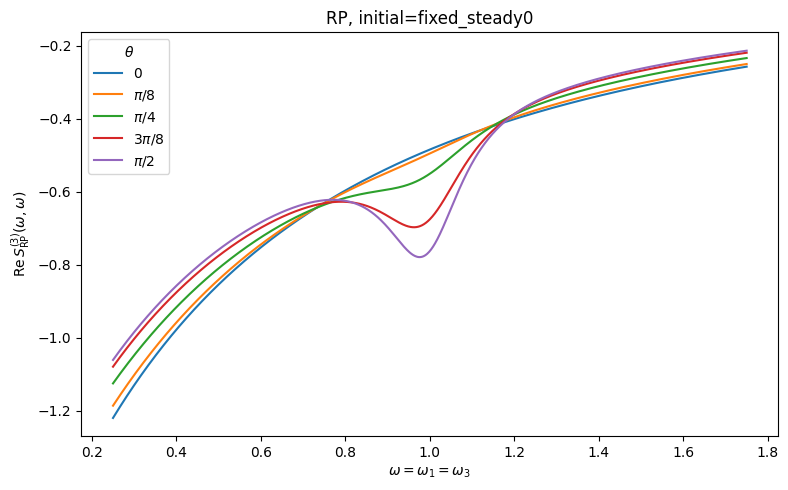

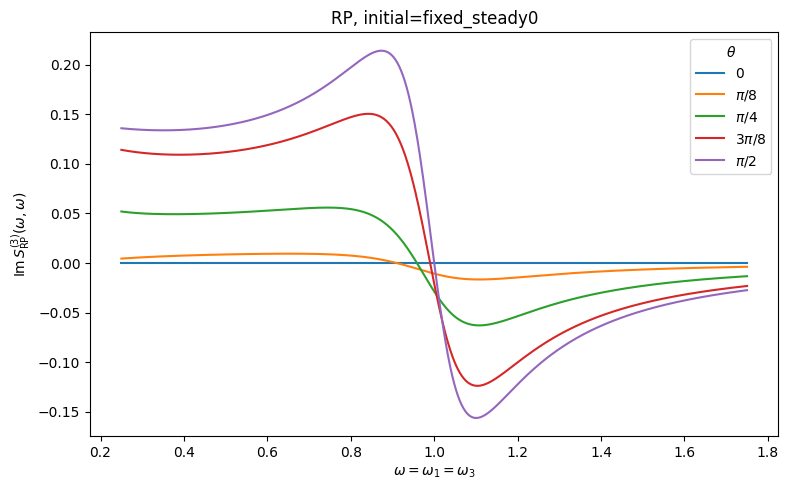


Computing NRP_fixed_steady0


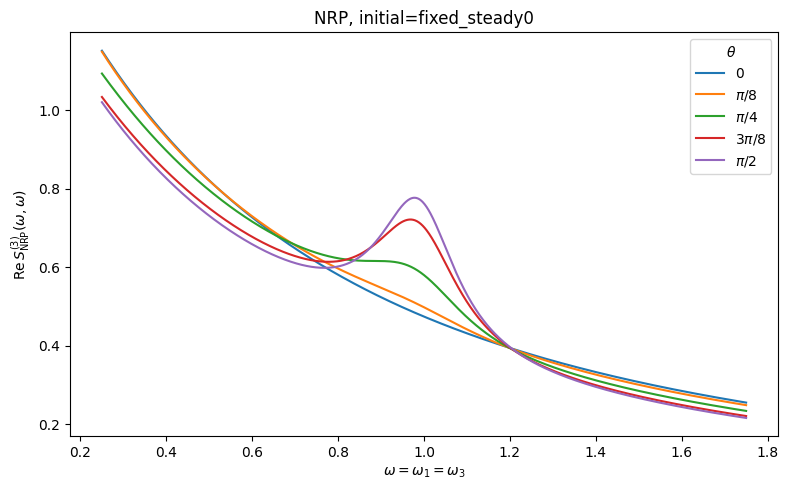

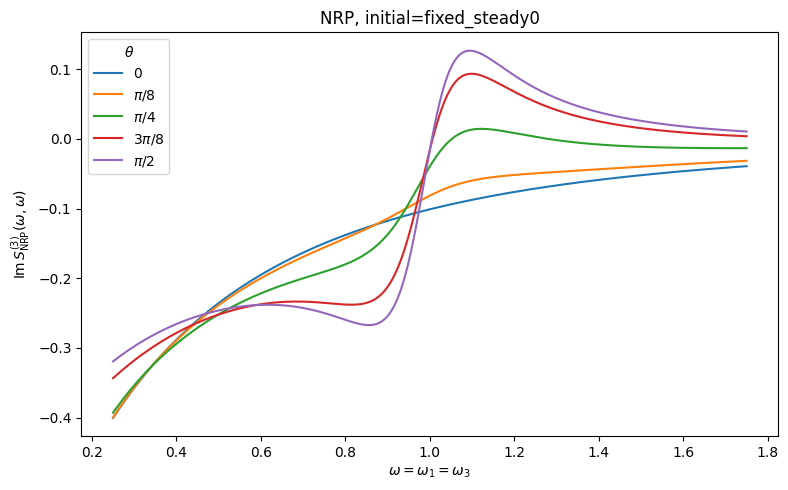


Computing RP_ground


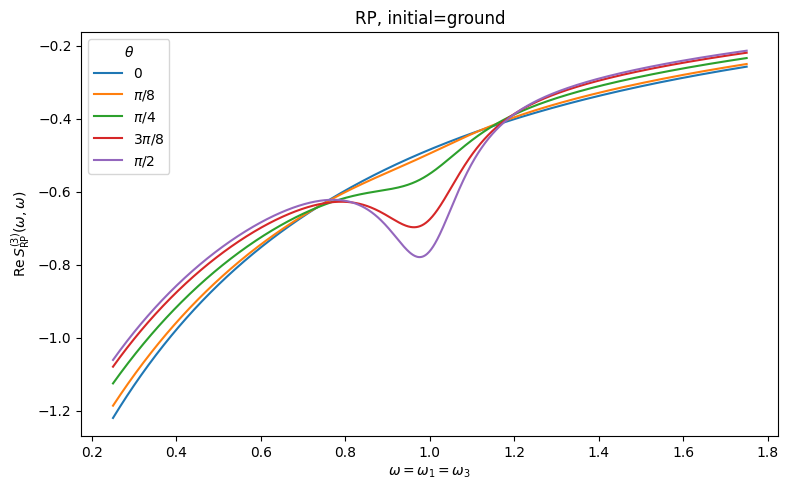

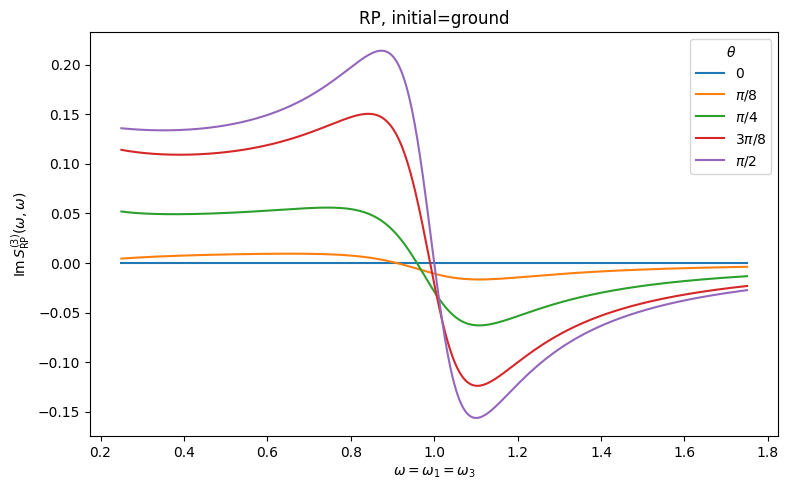


Computing NRP_ground


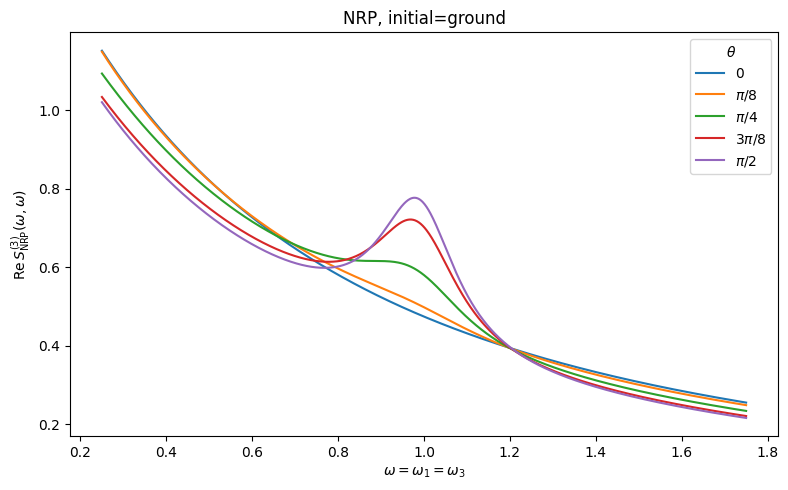

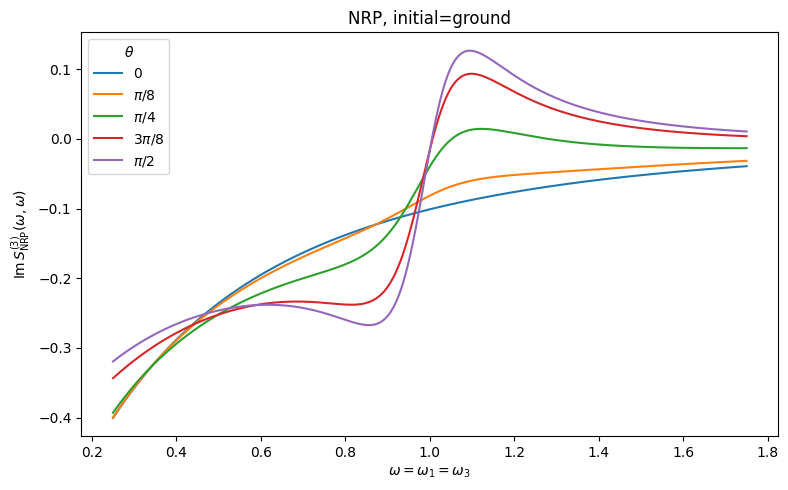

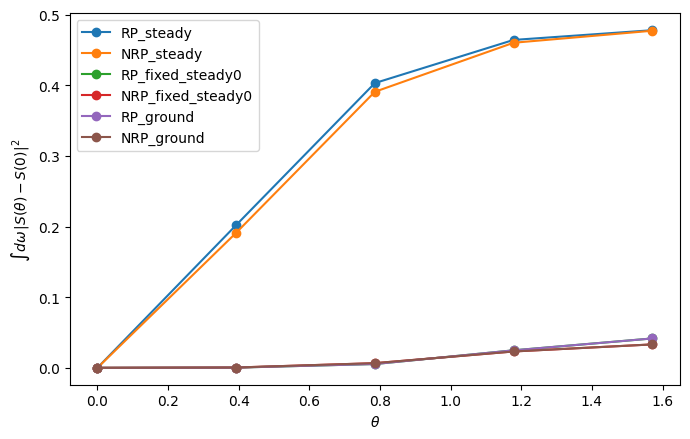

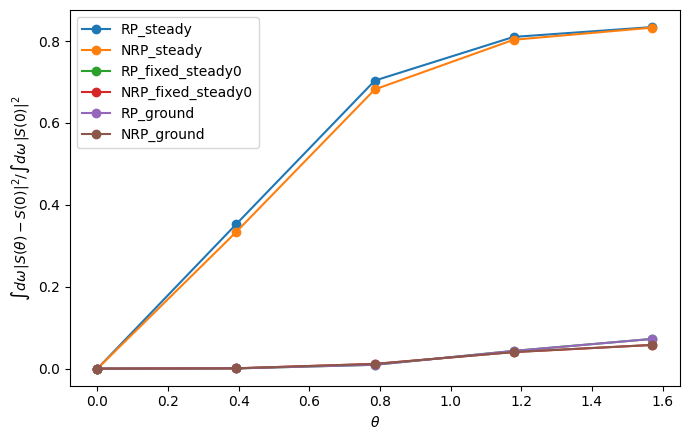


Final deformation summary
--------------------------------------------------------------------------------
RP_steady          absolute final = 4.778959e-01   normalized final = 8.340646e-01
NRP_steady         absolute final = 4.771294e-01   normalized final = 8.327268e-01
RP_fixed_steady0   absolute final = 4.159219e-02   normalized final = 7.259022e-02
NRP_fixed_steady0  absolute final = 3.316013e-02   normalized final = 5.787389e-02
RP_ground          absolute final = 4.159219e-02   normalized final = 7.259022e-02
NRP_ground         absolute final = 3.316013e-02   normalized final = 5.787389e-02


NameError: name 'theta_values' is not defined

In [ ]:
results2 = run_initial_state_comparison()


# Compare heterodyne detection components
for det in ["full", "+", "-"]:
    results_det = {
        sector: signal_sweep(
            theta_values, omegas,
            sector=sector,
            detection=det,
            initial="steady",
            tau2=tau2,
            w0=w0,
            gamma_phi=gamma_phi,
            gamma1=gamma1,
            eta=eta,
        )
        for sector in ["RP", "NRP"]
    }

In [ ]:
def zero_mode_overlap_after_first_interaction(theta, sector="RP", omega=1.0,
                                              initial="steady",
                                              w0=1.0, gamma_phi=0.1, gamma1=0.02):
    L = liouvillian(w0=w0, gamma_phi=gamma_phi, theta=theta, gamma1=gamma1)
    rho0 = initial_state(L, mode=initial,
                         L_ref=liouvillian(w0=w0, gamma_phi=gamma_phi,
                                           theta=0.0, gamma1=gamma1))

    evals_R, VR = np.linalg.eig(L)
    i0 = np.argmin(np.abs(evals_R))
    R0 = VR[:, i0]

    evals_L, VL = np.linalg.eig(L.conj().T)
    j0 = np.argmin(np.abs(evals_L))
    L0 = VL[:, j0]

    # biorthogonal normalize
    L0 = L0 / (L0.conj().T @ R0)

    rows = []
    for p in get_sector_pathways(sector):
        J1 = interaction_super(*p[0])
        v = J1 @ rho0
        overlap = L0.conj().T @ v
        rows.append((pathway_label(p), pathway_phase_signature(p), overlap))

    return rows

In [ ]:
for sector in ["RP", "NRP"]:
    print(sector)
    for label, sig, ov in zero_mode_overlap_after_first_interaction(np.pi/2, sector):
        print(label, sig, ov)

RP
NRP
